## Presentation 5 - 25/05
Next steps
from presentation:
- estimation of distribution of rotation angle
- whole model validation via goodness-of-fit tests
- comparison with Brownian motion baseline
- memory effects

Suggestions from seminar
- stabpy package JuliaKonczal
- angles will be interesting
- are angles related to step length?

our other ideas:
filtering smallest steps, resampling for bigger time window (I think dr Balcerek suggested this as well), deeper analysis of data with split for foraging/migration

In this notebook we dive deeper into white stork data anlysis.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from src.simulators import *
from src.estimators import *

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("tab10")
sns.set_style("darkgrid")

## 1. Data loading and additional transformation

In [2]:
DATA_PATH = "data/whitestork/clean_df_whitestork_steps.csv"
df_whitestorks = pd.read_csv(DATA_PATH)
print(f"\nClean dataset : {len(df_whitestorks):,} rows, {df_whitestorks['individual_id'].nunique()} individuals")
DATA_PATH = "data/whitestork/clean_df_whitestork_steps.csv"
df_whitestorks = pd.read_csv(DATA_PATH)
print(f"\nClean dataset : {len(df_whitestorks):,} rows, {df_whitestorks['individual_id'].nunique()} individuals")


Clean dataset : 1,492,640 rows, 72 individuals

Clean dataset : 1,492,640 rows, 72 individuals


In [3]:
df_whitestorks

,event-id,visible,timestamp,lon,lat,study-specific-measurement,sensor-type,taxon,tag-local-identifier,individual_id,study-name,dt_sec,step_m,speed_ms,turn_angle
0,704270427,True,2013-07-15 09:25:07+00:00,8.932201,47.751430,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,3030,Benjamin (DER AN867),MPIO white stork lifetime tracking data (2013-...,300.000,1.623661,0.005412,-33.478107
1,704270428,True,2013-07-15 09:30:09+00:00,8.932202,47.751435,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,3030,Benjamin (DER AN867),MPIO white stork lifetime tracking data (2013-...,302.000,0.482094,0.001596,147.152301
2,704270429,True,2013-07-15 09:35:07+00:00,8.932211,47.751417,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,3030,Benjamin (DER AN867),MPIO white stork lifetime tracking data (2013-...,298.000,2.028275,0.006806,70.959917
3,704270430,True,2013-07-15 09:40:07+00:00,8.931806,47.751208,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,3030,Benjamin (DER AN867),MPIO white stork lifetime tracking data (2013-...,300.000,38.138567,0.127129,35.479312
4,704270431,True,2013-07-15 09:45:08+00:00,8.931777,47.751208,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,3030,Benjamin (DER AN867),MPIO white stork lifetime tracking data (2013-...,301.000,2.184439,0.007257,140.052751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1492635,703895414,True,2014-06-24 19:35:13.001000+00:00,-1.189166,42.056156,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,2541,Zozu (DER AL581),MPIO white stork lifetime tracking data (2013-...,301.003,4.123806,0.013700,-124.029728
1492636,703895415,True,2014-06-24 19:40:12.001000+00:00,-1.189252,42.056122,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,2541,Zozu (DER AL581),MPIO white stork lifetime tracking data (2013-...,299.000,8.025423,0.026841,-135.262612
1492637,703895416,True,2014-06-24 19:45:11+00:00,-1.189030,42.056073,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,2541,Zozu (DER AL581),MPIO white stork lifetime tracking data (2013-...,298.999,19.119698,0.063946,-116.639854
1492638,703895417,True,2014-06-24 19:50:11.001000+00:00,-1.189053,42.056170,LifeTrack White Stork SWGermany 2013,gps,Ciconia ciconia,2541,Zozu (DER AL581),MPIO white stork lifetime tracking data (2013-...,300.001,10.969964,0.036566,75.273374


**Filtering step lengths**

When a tracking device records a very small step length, it means the stork is sitting completely still (resting, sleeping, or nesting). Because animals spend a lot of time resting, tracking data will contain a massive spikes near zeros. As was suggested during seminar we will filter out these observations.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_whitestorks['timestamp'] = pd.to_datetime(df_whitestorks['timestamp'], format='ISO8601')
df_whitestorks = df_whitestorks.sort_values(by=['individual_id', 'timestamp']).reset_index(drop=True)

initial_count = len(df_whitestorks)
print(f"Total raw rows loaded: {initial_count:,}")

# recalculate Time Differences (dt_sec) between consecutive fixes per bird
df_whitestorks['dt_sec'] = df_whitestorks.groupby('individual_id')['timestamp'].diff().dt.total_seconds()

# check for extreme values
raw_min_speed = df_whitestorks['speed_ms'].min()
raw_max_speed = df_whitestorks['speed_ms'].max()
raw_min_step = df_whitestorks['step_m'].min()
raw_max_step = df_whitestorks['step_m'].max()
print(f"Minimum Speed: {raw_min_speed} m/s")
print(f"Maximum Speed: {raw_max_speed} m/s")
print(f"Minimum Step: {raw_min_step} m")
print(f"Maximum Step: {raw_max_step} m")

MIN_SPEED = 0.005  # m/s #max 1m/5min
MAX_SPEED = 30.0  # m/s

# Define a tight window around the 5-minute (300s) expected interval
MIN_TIME_GAP = 250.0 # seconds
MAX_TIME_GAP = 350.0 # seconds

df_clean_steps = df_whitestorks.dropna(subset=['step_m', 'speed_ms', 'turn_angle', 'dt_sec']).copy()

df_clean_steps = df_clean_steps[
    (df_clean_steps['speed_ms'] >= MIN_SPEED) & 
    (df_clean_steps['speed_ms'] <= MAX_SPEED)
]

# Apply the double-sided time filter
df_clean_steps = df_clean_steps[
    (df_clean_steps['dt_sec'] >= MIN_TIME_GAP) & 
    (df_clean_steps['dt_sec'] <= MAX_TIME_GAP)
]

final_count = len(df_clean_steps)
removed_count = initial_count - final_count

print(f"rows filtered out: {removed_count:,} ({removed_count/initial_count:.2%})")
print(f"rows retained {final_count:,} ({final_count/initial_count:.2%})")

print(f"cleaned speed range: [{df_clean_steps['speed_ms'].min()} to {df_clean_steps['speed_ms'].max()}] m/s")
print(f"cleaned step range [{df_clean_steps['step_m'].min():.2f} to {df_clean_steps['step_m'].max():.2f}] meters")

print("=" * 80)

Total raw rows loaded: 1,492,640
Minimum Speed: 3.9328217215122633e-07 m/s
Maximum Speed: 1031.3628415681585 m/s
Minimum Step: 0.0063067518201922 m
Maximum Step: 493325.0715115712 m
rows filtered out: 311,306 (20.86%)
rows retained 1,181,334 (79.14%)
cleaned speed range: [0.0050000214938155 to 29.964156711111283] m/s
cleaned step range [1.26 to 9826.80] meters


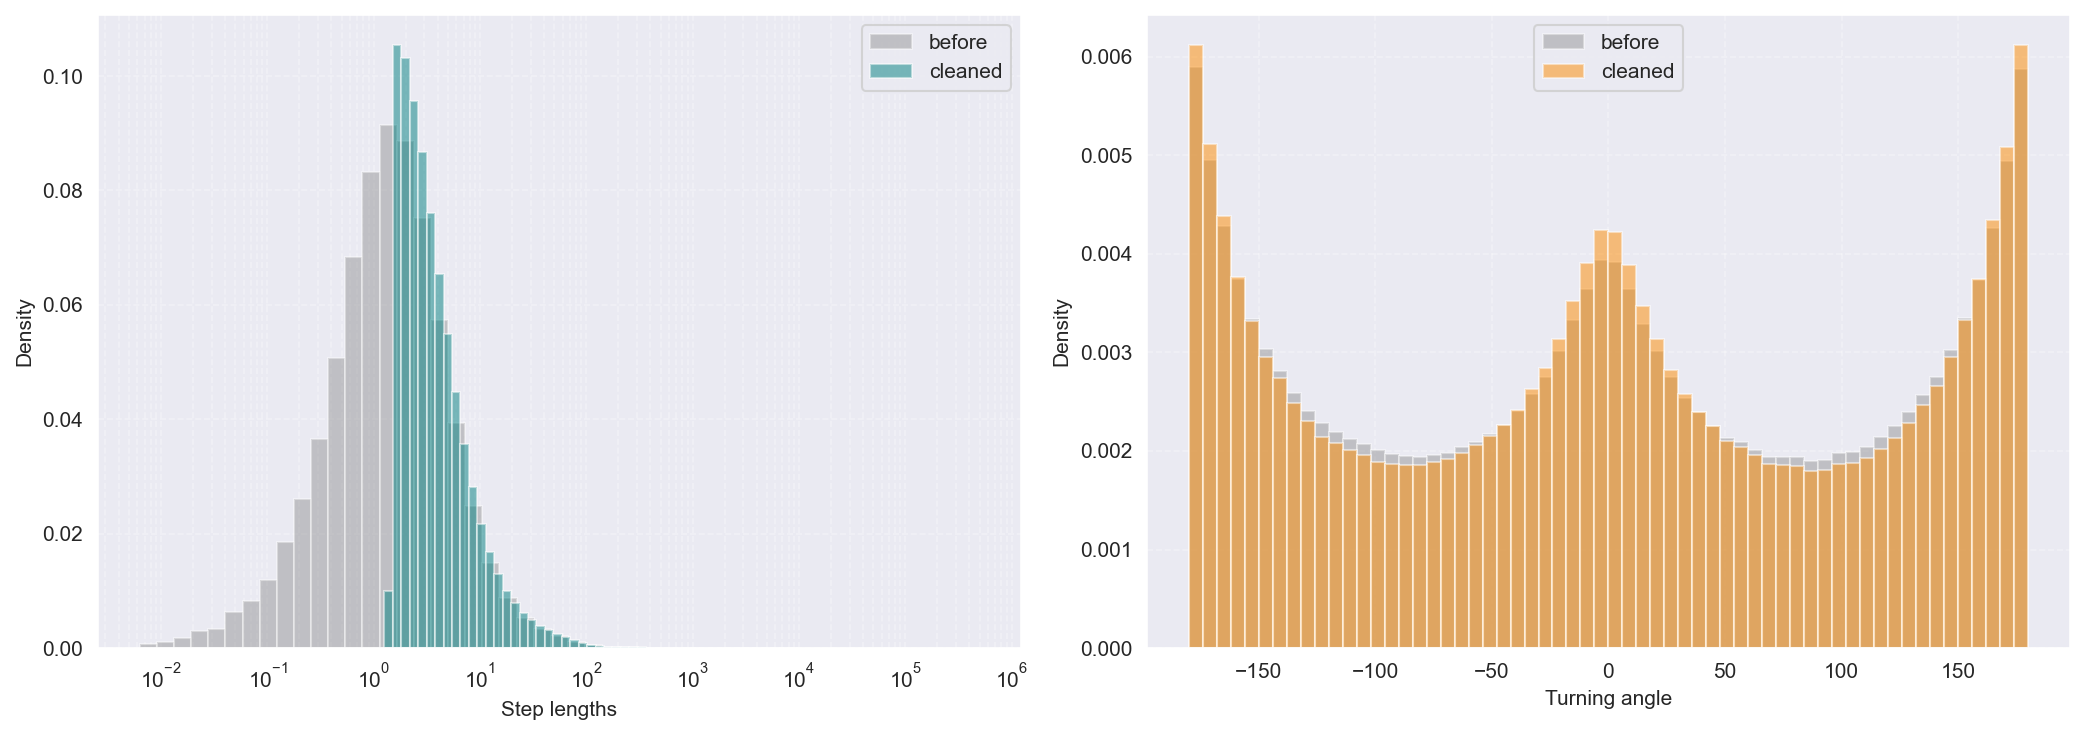

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_raw = np.logspace(np.log10(df_whitestorks['step_m'].min()), np.log10(df_whitestorks['step_m'].max()), 50)
bins_clean = np.logspace(np.log10(df_clean_steps['step_m'].min()), np.log10(df_clean_steps['step_m'].max()), 50)

axes[0].hist(df_whitestorks['step_m'].dropna(), bins=bins_raw, alpha=0.4, color='gray', label='before', density=True)
axes[0].hist(df_clean_steps['step_m'], bins=bins_clean, alpha=0.5, color='teal', label='cleaned', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Step lengths')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, which="both", ls="--", alpha=0.3)

axes[1].hist(df_whitestorks['turn_angle'].dropna(), bins=60, alpha=0.4, color='gray', label='before', density=True)
axes[1].hist(df_clean_steps['turn_angle'], bins=60, alpha=0.5, color='darkorange', label='cleaned', density=True)
axes[1].set_xlabel('Turning angle')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Estimation and validation with stabpy

First, we will compare estimated parameters obtained in [previous notebook](02_Levy_Flight_Fitting_whitestorks.ipynb) using our implementations on data before transformation with those resulting from [stabpy](https://github.com/juliakonczal/StabPy?tab=readme-ov-file) package on modified data. Then, we will use this package to further assert goodness of fit with statistical tests on top of preliminary validation performed in previous notebook.

Global parameters estimated previously for the pooled `step_m` values.
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>alpha</th>
      <th>beta</th>
      <th>sigma</th>
      <th>mu</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>McCulloch</th>
      <td>0.5008</td>
      <td>1.0000</td>
      <td>22.916</td>
      <td>9.8505</td>
    </tr>
    <tr>
      <th>Koutrouvelis</th>
      <td>0.5313</td>
      <td>0.9749</td>
      <td>4.545</td>
      <td>-0.4139</td>
    </tr>
  </tbody>
</table>
</div>

We also performed estimation for individual birds. Here, we present those with the most observations.

In [4]:
per_bird_df = pd.read_csv("data/whitestork/per_bird_est.csv")
top10 = (
    per_bird_df["n"]
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
top_df = per_bird_df.loc[top10]
top_df

,Unnamed: 0,n,alpha_mcc,beta_mcc,sigma_mcc,mu_mcc,alpha_kou,beta_kou,sigma_kou,mu_kou
18,Karamell (DER AL582),77907.0,0.501124,1.0,10.384145,6.114065,0.567840,0.958588,2.861447,-0.265264
19,DER AR446,77407.0,0.501156,1.0,36.977195,14.146884,0.351921,0.852027,4.912527,0.709322
9,DER AR445,77023.0,0.500869,1.0,61.666755,15.560465,0.388950,0.814807,5.185812,0.761782
8,DER AR444,76970.0,0.500707,1.0,50.604462,12.780921,0.437081,0.831121,4.644710,0.585916
16,C7X7,74401.0,0.500996,1.0,23.734409,11.276587,0.589439,0.958921,5.143190,-0.979831
41,Zozu (DER AL581),72014.0,0.555840,1.0,13.087514,11.515954,0.580291,1.000000,5.851334,-1.757732
20,Yolo (DER AN861),71644.0,0.501188,1.0,38.155298,16.291378,0.521630,0.973739,7.392746,-0.696647
31,Sierit (DER AN858),69985.0,0.502818,1.0,12.858219,12.019048,0.663536,1.000000,5.808097,-3.797686
10,PLG 5P311,69974.0,0.500874,1.0,42.986259,14.857240,0.425253,0.884502,5.696188,0.466501
11,DER AP809,66041.0,0.500891,1.0,40.869502,14.898272,0.521808,0.914032,6.176266,-0.196809


Now, we will use stabpy implementations of these estimators to compare our results.
First, we will consider pooled observations.

In [60]:
import stabpy

step_vals = df_clean_steps["step_m"].values

#mcculloch
alpha_q, sigma_q, beta_q, mu_q = stabpy.stabcull(step_vals)
print(f"Quantile estimates: α={alpha_q:.3f}, β={beta_q:.3f}, sigma={sigma_q:.3f}, mu={mu_q:.3f}")

# Estimate parameters (regression method - more accurate) - Koutrouvelis
alpha_r, sigma_r, beta_r, mu_r = stabpy.stabreg(step_vals)
print(f"Regression estimates: α={alpha_r:.3f}, β={beta_r:.3f}, sigma={sigma_r:.3f}, mu={mu_r:.3f}")

Quantile estimates: α=0.514, β=1.000, sigma=5.720, mu=-2.235
Regression estimates: α=0.449, β=1.000, sigma=5.238, mu=1.042


We observe discrepancy between parameters estimated before, especially $\sigma, \mu$ parameters for McCulloch method, suggesting differences in implementations. Even taking into account modification of step_lengths considered. After deeper comparison we found the following differences:

1. McCulloch (Quantile)

The variations in $\sigma$ and $\mu$ are due to different levels of completeness in implementing McCulloch’s 1986 specification:
 The `stabpy` library implements the full McCulloch algorithm, using `psi3` to normalize the scale parameter and `psi4` to adjust the location parameter for skewness. 
 Our code uses a simplified baseline approximation ($\sigma = \frac{q_{75} - q_{25}}{2}$ and $\mu = q_{50}$), which is close to `psi3` for most of the valueas. However, for an alpha near $0.5$ with maximum skewness ($\beta \approx 1$), the true lookup divisor in `psi3` is $\approx 9.14$, which explains why our simplified scale estimate is inflated ($\sim 22.9$) compared to `stabpy` ($\sim 5.2$).

2. Koutrouvelis (Regression)

Both implementations show strong alignment for the regression method. However, their execution strategies differ:
Our implementation employs a direct, single-pass regression over a static linear frequency grid ($t \in [0.1, 1.0]$).
* **`stabpy` Implementation:** Implements Koutrouvelis’s full iterative framework. It standardizes the sample data at each step and dynamically adjusts the frequency grid size (up to $K=68$ points for $\alpha \approx 0.5$) based on the data's tail behavior. This is why it can produce more accurate results.

For the final analysis, we will use the parameters from the full iterative regression method.

We focus on observations for individual birds from now on - will calculate use stabpy estimates and validate them, performing goodness of fit tests for Koutrouvelis method.

**Disclosure**: Below we use only slightly modified for our needs function taken from stabpy package source code.

In [ ]:
from tqdm import tqdm
import stabpy

# modified goodness of fit test copied from stabpy source with added tqdm and prints for tests
def custom_stabtest(x, ilp=500):
    """
        Interpretation:
        - Small p-values (< 0.05) suggest the data is not from a stable distribution
        - Large p-values indicate the stable distribution fits the data well
        - Different tests have different sensitivities to various departures from
        the null hypothesis
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    n = x.size
    
    # Estimate parameters using the robust regression method
    alpha, sigma, beta, mu = stabpy.stabreg(x)
    print(f"\n Stabtest fitted params Alpha={alpha:.4f}, Sigma={sigma:.4f}, Beta={beta:.4f}, Mu={mu:.4f}")
    
    # Initialize result array
    y = np.zeros(14, dtype=float)
    
    # Compute sorted empirical CDF values
    z = np.sort(stabpy.stabcdf(x, alpha, sigma, beta, mu))
    
    # Kolmogorov-Smirnov statistic: maximum distance between empirical and theoretical CDF
    kp = np.max(np.arange(1, n+1)/n - z)  # maximum positive deviation
    km = np.max(z - np.arange(0, n)/n)    # maximum negative deviation
    Dp = np.max([kp, km]) * (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))
    
    # Kuiper statistic: sum of maximum positive and negative deviations
    Vp = (kp + km) * (np.sqrt(n) + 0.155 + 0.24/np.sqrt(n))
    
    # Cramér-von Mises statistic: integrated squared distance
    W2 = np.sum((z - (np.arange(1, 2*n, 2)/(2*n)))**2) + 1/(12*n)
    
    # Watson statistic: Cramér-von Mises with location correction
    U2 = W2 - n * (np.mean(z) - 0.5)**2
    
    # Modified statistics with finite-sample corrections
    W2p = (W2 - 0.4/n + 0.6/n**2) * (1 + 1/n)
    U2p = (U2 - 0.1/n + 0.1/n**2) * (1 + 0.8/n)
    
    # Anderson-Darling statistic: weighted squared distance (more weight in tails)
    A2p = - (1/n) * np.dot(np.arange(1, 2*n, 2), 
                            (np.log(z) + np.log(1 - z[::-1]))) - n
    
    # print(f" KS={Dp:.4f}, Kuiper={Vp:.4f}, CvM={W2p:.4f}, Watson={U2p:.4f}, AD={A2p:.4f}")
    # print(f"Running Monte Carlo...")
    
    # Generate random trajectories for Monte Carlo validation
    proba = sigma * stabpy.stabrnd(alpha, beta, n, ilp) + mu
    probat = np.zeros((ilp, 5), dtype=float)
    
    for i in tqdm(range(ilp)):
        # Estimate parameters for simulated sample
        a_i, s_i, b_i, m_i = stabpy.stabreg(proba[:, i])
        z_i = np.sort(stabpy.stabcdf(proba[:, i], a_i, s_i, b_i, m_i))
        
        # Compute test statistics for simulated sample
        kp = np.max(np.arange(1, n+1)/n - z_i)
        km = np.max(z_i - np.arange(0, n)/n)
        probat[i, 0] = np.max([kp, km]) * (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))
        probat[i, 1] = (kp + km) * (np.sqrt(n) + 0.155 + 0.24/np.sqrt(n))
        
        W2 = np.sum((z_i - (np.arange(1, 2*n, 2)/(2*n)))**2) + 1/(12*n)
        U2 = W2 - n * (np.mean(z_i) - 0.5)**2
        probat[i, 2] = (W2 - 0.4/n + 0.6/n**2) * (1 + 1/n)
        probat[i, 3] = (U2 - 0.1/n + 0.1/n**2) * (1 + 0.8/n)
        probat[i, 4] = - (1/n) * np.dot(np.arange(1, 2*n, 2), 
                                         (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
    
    # Compile results
    y[0:4] = [alpha, sigma, beta, mu]
    pt = np.array([Dp, Vp, W2p, U2p, A2p], dtype=float)
    y[4:9] = pt
    
    # Compute p-values: proportion of simulated statistics exceeding observed
    pvals = np.array([(probat[:, j] > pt[j]).sum()/ilp for j in range(5)], dtype=float)
    y[9:14] = pvals
    
    return y

We will estimate parameters and perform tests for all birds with at least 4000 observations. For computational speed we will randomly subsample 5000 observations for those with more, since our data has up to 78000 observations for individual birds, which made computations too demanding for our computers without subsampling in terms of memory usage.


In [74]:
import os
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import levy_stable
import stabpy
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

os.makedirs("stable_plots/passed", exist_ok=True)
os.makedirs("stable_plots/failed", exist_ok=True)

bird_counts = df_clean_steps.groupby("individual_id").size()
filtered_birds = bird_counts[bird_counts.between(10000, 30000)].sort_values(ascending=False).index.tolist()

print("=" * 85)
print(f"{len(filtered_birds)} birds with between 10000 and 30000 points")
print("=" * 85)

all_birds_database = {}
MC_ITERATIONS = 500 

for rank, bird_id in enumerate(filtered_birds):

    df_bird_full = df_clean_steps[df_clean_steps["individual_id"] == bird_id].sort_values("timestamp")
    s_b = df_bird_full["step_m"].values
    total_obs = len(s_b)
    
    try:
        aq, sq, bq, mq = stabpy.stabcull(s_b)
    except Exception:
        aq, sq, bq, mq = 0, 0, 0, 0

    try:
        ar, sr, br, mr = stabpy.stabreg(s_b)
    except Exception:
        ar, sr, br, mr = None, None, None, None
        
    if ar is None:
        print(f"'{bird_id}' failed regression")
        continue  
    print("Estimated for full data", ar, sr, br, mr)
    np.random.seed(42)
    sample_size = min(total_obs, 50000)
    s_b_test = np.random.choice(s_b, size=sample_size, replace=False)
        

    test_res = custom_stabtest(s_b_test, ilp=MC_ITERATIONS)

        
    pvals = test_res[9:14]  # captured empirical p-values
    passing_tests_count = np.sum(pvals >= 0.05)
    
    safe_bird_name = str(bird_id).replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    
    if passing_tests_count >= 3:
        status_folder = "passed"
        print(f"'{bird_id}' passed validation ({passing_tests_count}/5 tests accepted).")
    else:
        status_folder = "failed"
        print(f"'{bird_id}' failed validation ({passing_tests_count}/5 tests accepted).")
        
    # Save the FULL DATASET parameters to your database
    all_birds_database[bird_id] = {
        "Total Observations (n)": total_obs,
        "Sample Evaluation Size": sample_size,
        "Passing Tests Count": passing_tests_count,
        "Status": "Passed" if passing_tests_count >= 3 else "Failed",
        "alpha_cull": aq, "beta_cull": bq, "sigma_cull": sq, "mu_cull": mq,
        "alpha_reg": ar, "beta_reg": br, "sigma_reg": sr, "mu_reg": mr,
        "p_KS": pvals[0], "p_Kuiper": pvals[1], "p_CvM": pvals[2], "p_Watson": pvals[3], "p_AD": pvals[4],
        "stat_KS": test_res[4], "stat_Kuiper": test_res[5], "stat_CvM": test_res[6], "stat_Watson": test_res[7], "stat_AD": test_res[8]
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"{bird_id}", fontweight="bold", fontsize=14)
    
    ax1 = axes[0, 0]
    bins = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 50)
    
    # Plotting the FULL empirical dataset
    ax1.hist(s_b, bins=bins, density=True, alpha=0.5, color="royalblue", edgecolor="white", label="Empirical steps (Full)")
    
    levy_stable.parameterization = 'S0'
    x_grid = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 300)
    
    # Using the FULL dataset parameters for the theoretical PDF
    pdf_fitted = levy_stable.pdf(x_grid, ar, br, loc=mr, scale=sr)
    
    ax1.plot(x_grid, pdf_fitted, color="darkorange", lw=2.5, label=f"Fitted PDF ($\\alpha$={ar:.2f})")
    ax1.set_xscale("log")
    ax1.set_xlabel("Step lengths (meters)")
    ax1.set_ylabel("Probability density")
    ax1.set_title('Histogram with PDF')
    ax1.grid(True, which="both", ls="--", alpha=0.3)
    ax1.legend()

    # --- (The rest of your plotting code remains the same, but use s_b_full where applicable) ---
    ax2 = axes[0, 1]
    s_b_sorted = np.sort(s_b)
    theoretical_cdf = stabpy.stabcdf(s_b_sorted, ar, sr, br, mr)
    empirical_cdf = np.arange(1, len(s_b)+1) / (len(s_b)+1)
    sample_indices = np.linspace(0, len(s_b)-1, min(1000, len(s_b))).astype(int)
    
    ax2.scatter(theoretical_cdf[sample_indices], empirical_cdf[sample_indices], 
                color="crimson", alpha=0.5, s=8, label="empirical quantiles", zorder=3)
    ax2.plot([0, 1], [0, 1], 'k--', label='theoretical fit', lw=1.5, zorder=2)
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Empirical quantiles')
    ax2.set_title('Q-Q Plot')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(s_b[:500], color="teal", linewidth=1.0, alpha=0.8)
    ax3.set_xlabel('($t$)')
    ax3.set_ylabel('Step (m)')
    ax3.set_title('First 500 steps')
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    params_quant = [aq, bq]
    params_reg = [ar, br]
    x_pos = np.arange(2)
    width = 0.35
    ax4.bar(x_pos - width/2, params_quant, width, label='Quantile (stabcull)', color="orange", alpha=0.8)
    ax4.bar(x_pos + width/2, params_reg, width, label='Regression (stabreg)', color="purple", alpha=0.8)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['$\\alpha$', '$\\beta$'])
    ax4.set_title('Parameter estimation comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    dashboard_destination = os.path.join("stable_plots", status_folder, f"dashboard_{safe_bird_name}.png")
    plt.savefig(dashboard_destination, dpi=150, bbox_inches='tight')
    plt.close()


per_bird_df = pd.DataFrame(all_birds_database).T

column_ordering = [
    "Total Observations (n)", "Sample Evaluation Size", "Passing Tests Count", "Status",
    "alpha_cull", "beta_cull", "sigma_cull", "mu_cull",
    "alpha_reg", "beta_reg", "sigma_reg", "mu_reg",
    "p_KS", "p_Kuiper", "p_CvM", "p_Watson", "p_AD",
    "stat_KS", "stat_Kuiper", "stat_CvM", "stat_Watson", "stat_AD"
]
per_bird_df = per_bird_df.reindex(columns=column_ordering)


display(per_bird_df.round(4))

8 birds with between 10000 and 30000 points
Estimated for full data 0.47802029220012493 9.843084008899321 0.876121725240982 1.3171981627696585

 Stabtest fitted params Alpha=0.4780, Sigma=9.8431, Beta=0.8761, Mu=1.3172


100%|██████████| 500/500 [08:18<00:00,  1.00it/s]


'Silvia (GRA51159)' failed validation (0/5 tests accepted).
Estimated for full data 0.5479607333489297 5.454164444575208 1.0 0.025063694520734092

 Stabtest fitted params Alpha=0.5480, Sigma=5.4542, Beta=1.0000, Mu=0.0251


100%|██████████| 500/500 [05:51<00:00,  1.42it/s]


'DER AP922' failed validation (0/5 tests accepted).
Estimated for full data 0.5228191837825575 5.490600254497535 0.9805310926550532 0.6308414549424874

 Stabtest fitted params Alpha=0.5228, Sigma=5.4906, Beta=0.9805, Mu=0.6308


...

100%|██████████| 500/500 [03:19<00:00,  2.51it/s]


'Cherry (DER AN859)' failed validation (1/5 tests accepted).
Estimated for full data 0.5771826011066062 1.810509943560935 1.0 0.8471340134636562

 Stabtest fitted params Alpha=0.5772, Sigma=1.8105, Beta=1.0000, Mu=0.8471


100%|██████████| 500/500 [03:06<00:00,  2.68it/s]


'DER AP927' failed validation (0/5 tests accepted).


,Total Observations (n),Sample Evaluation Size,Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,...,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
Silvia (GRA51159),25122,25122,0,Failed,0.776442,1.0,110.915665,-537.325511,0.47802,0.876122,...,0.0,0.0,0.0,0.0,0.0,21.877588,27.25477,84.650545,28.807891,744.932269
DER AP922,23400,23400,0,Failed,0.622912,1.0,5.670725,-3.110876,0.547961,1.0,...,0.002,0.002,0.002,0.002,0.002,10.039511,13.383585,14.486704,14.388324,122.220217
Dilya,21215,21215,2,Failed,0.516181,1.0,4.964575,0.386614,0.522819,0.980531,...,0.0,0.0,0.092,0.004,0.17,3.383244,4.999908,1.00183,0.985436,18.157876
DER AR436,20452,20452,5,Passed,0.514095,1.0,10.062304,-11.037666,0.418076,0.791867,...,0.068,0.07,0.068,0.07,0.066,12.665616,17.679952,74.062937,10.39698,481.343544
C666,19498,19498,5,Passed,0.537381,1.0,21.977337,-28.482392,0.303489,0.931951,...,0.258,0.258,0.258,0.258,0.258,14.405283,19.659391,22.041341,21.864931,219.200151
DER AP921,16030,16030,0,Failed,0.827057,1.0,3.968519,-12.766102,0.733851,1.0,...,0.002,0.002,0.002,0.002,0.002,7.62695,9.52392,16.450143,7.205315,130.689638
Cherry (DER AN859),12999,12999,1,Failed,0.515672,1.0,2.253041,2.455293,0.605462,0.983291,...,0.002,0.0,0.032,0.006,0.242,2.920636,5.359954,2.024189,1.324521,20.00143
DER AP927,12181,12181,0,Failed,0.742513,1.0,2.211108,-3.49729,0.577183,1.0,...,0.004,0.0,0.002,0.0,0.0,3.769939,7.351278,6.661593,6.661504,56.338639


In [80]:
pd.set_option('display.max_columns', None)

In [81]:
display(per_bird_df)

,Total Observations (n),Sample Evaluation Size,Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,sigma_reg,mu_reg,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
Silvia (GRA51159),25122,25122,0,Failed,0.776442,1.0,110.915665,-537.325511,0.47802,0.876122,9.843084,1.317198,0.0,0.0,0.0,0.0,0.0,21.877588,27.25477,84.650545,28.807891,744.932269
DER AP922,23400,23400,0,Failed,0.622912,1.0,5.670725,-3.110876,0.547961,1.0,5.454164,0.025064,0.002,0.002,0.002,0.002,0.002,10.039511,13.383585,14.486704,14.388324,122.220217
Dilya,21215,21215,2,Failed,0.516181,1.0,4.964575,0.386614,0.522819,0.980531,5.4906,0.630841,0.0,0.0,0.092,0.004,0.17,3.383244,4.999908,1.00183,0.985436,18.157876
DER AR436,20452,20452,5,Passed,0.514095,1.0,10.062304,-11.037666,0.418076,0.791867,4.999844,1.709513,0.068,0.07,0.068,0.07,0.066,12.665616,17.679952,74.062937,10.39698,481.343544
C666,19498,19498,5,Passed,0.537381,1.0,21.977337,-28.482392,0.303489,0.931951,8.345373,1.583851,0.258,0.258,0.258,0.258,0.258,14.405283,19.659391,22.041341,21.864931,219.200151
DER AP921,16030,16030,0,Failed,0.827057,1.0,3.968519,-12.766102,0.733851,1.0,3.406773,-2.964501,0.002,0.002,0.002,0.002,0.002,7.62695,9.52392,16.450143,7.205315,130.689638
Cherry (DER AN859),12999,12999,1,Failed,0.515672,1.0,2.253041,2.455293,0.605462,0.983291,3.333631,0.530057,0.002,0.0,0.032,0.006,0.242,2.920636,5.359954,2.024189,1.324521,20.00143
DER AP927,12181,12181,0,Failed,0.742513,1.0,2.211108,-3.49729,0.577183,1.0,1.81051,0.847134,0.004,0.0,0.002,0.0,0.0,3.769939,7.351278,6.661593,6.661504,56.338639


In [84]:
import os
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import levy_stable
import stabpy
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

os.makedirs("stable_plots2/passed", exist_ok=True)
os.makedirs("stable_plots2/failed", exist_ok=True)

bird_counts = df_clean_steps.groupby("individual_id").size()
filtered_birds = bird_counts[bird_counts.between(30000, 50000)].sort_values(ascending=False).index.tolist()

print("=" * 85)
print(f"{len(filtered_birds)} birds with between 30000 and 50000 points")
print("=" * 85)

all_birds_database = {}
MC_ITERATIONS = 500 

for rank, bird_id in enumerate(filtered_birds):

    df_bird_full = df_clean_steps[df_clean_steps["individual_id"] == bird_id].sort_values("timestamp")
    s_b = df_bird_full["step_m"].values
    total_obs = len(s_b)
    
    try:
        aq, sq, bq, mq = stabpy.stabcull(s_b)
    except Exception:
        aq, sq, bq, mq = 0, 0, 0, 0

    try:
        ar, sr, br, mr = stabpy.stabreg(s_b)
    except Exception:
        ar, sr, br, mr = None, None, None, None
        
    if ar is None:
        print(f"'{bird_id}' failed regression")
        continue  
    print("Estimated for full data", ar, sr, br, mr)
    np.random.seed(42)
    sample_size = min(total_obs, 50000)
    s_b_test = np.random.choice(s_b, size=sample_size, replace=False)
        

    test_res = custom_stabtest(s_b_test, ilp=MC_ITERATIONS)

        
    pvals = test_res[9:14]  # captured empirical p-values
    passing_tests_count = np.sum(pvals >= 0.05)
    
    safe_bird_name = str(bird_id).replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    
    if passing_tests_count >= 3:
        status_folder = "passed"
        print(f"'{bird_id}' passed validation ({passing_tests_count}/5 tests accepted).")
    else:
        status_folder = "failed"
        print(f"'{bird_id}' failed validation ({passing_tests_count}/5 tests accepted).")
        
    # Save the FULL DATASET parameters to your database
    all_birds_database[bird_id] = {
        "Total Observations (n)": total_obs,
        "Sample Evaluation Size": sample_size,
        "Passing Tests Count": passing_tests_count,
        "Status": "Passed" if passing_tests_count >= 3 else "Failed",
        "alpha_cull": aq, "beta_cull": bq, "sigma_cull": sq, "mu_cull": mq,
        "alpha_reg": ar, "beta_reg": br, "sigma_reg": sr, "mu_reg": mr,
        "p_KS": pvals[0], "p_Kuiper": pvals[1], "p_CvM": pvals[2], "p_Watson": pvals[3], "p_AD": pvals[4],
        "stat_KS": test_res[4], "stat_Kuiper": test_res[5], "stat_CvM": test_res[6], "stat_Watson": test_res[7], "stat_AD": test_res[8]
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"{bird_id}", fontweight="bold", fontsize=14)
    
    ax1 = axes[0, 0]
    bins = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 50)
    
    # Plotting the FULL empirical dataset
    ax1.hist(s_b, bins=bins, density=True, alpha=0.5, color="royalblue", edgecolor="white", label="Empirical steps (Full)")
    
    levy_stable.parameterization = 'S0'
    x_grid = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 300)
    
    # Using the FULL dataset parameters for the theoretical PDF
    pdf_fitted = levy_stable.pdf(x_grid, ar, br, loc=mr, scale=sr)
    
    ax1.plot(x_grid, pdf_fitted, color="darkorange", lw=2.5, label=f"Fitted PDF ($\\alpha$={ar:.2f})")
    ax1.set_xscale("log")
    ax1.set_xlabel("Step lengths (meters)")
    ax1.set_ylabel("Probability density")
    ax1.set_title('Histogram with PDF')
    ax1.grid(True, which="both", ls="--", alpha=0.3)
    ax1.legend()

    # --- (The rest of your plotting code remains the same, but use s_b_full where applicable) ---
    ax2 = axes[0, 1]
    s_b_sorted = np.sort(s_b)
    theoretical_cdf = stabpy.stabcdf(s_b_sorted, ar, sr, br, mr)
    empirical_cdf = np.arange(1, len(s_b)+1) / (len(s_b)+1)
    sample_indices = np.linspace(0, len(s_b)-1, min(1000, len(s_b))).astype(int)
    
    ax2.scatter(theoretical_cdf[sample_indices], empirical_cdf[sample_indices], 
                color="crimson", alpha=0.5, s=8, label="empirical quantiles", zorder=3)
    ax2.plot([0, 1], [0, 1], 'k--', label='theoretical fit', lw=1.5, zorder=2)
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Empirical quantiles')
    ax2.set_title('Q-Q Plot')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(s_b[:500], color="teal", linewidth=1.0, alpha=0.8)
    ax3.set_xlabel('($t$)')
    ax3.set_ylabel('Step (m)')
    ax3.set_title('First 500 steps')
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    params_quant = [aq, bq]
    params_reg = [ar, br]
    x_pos = np.arange(2)
    width = 0.35
    ax4.bar(x_pos - width/2, params_quant, width, label='Quantile (stabcull)', color="orange", alpha=0.8)
    ax4.bar(x_pos + width/2, params_reg, width, label='Regression (stabreg)', color="purple", alpha=0.8)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['$\\alpha$', '$\\beta$'])
    ax4.set_title('Parameter estimation comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    dashboard_destination = os.path.join("stable_plots2", status_folder, f"dashboard_{safe_bird_name}.png")
    plt.savefig(dashboard_destination, dpi=150, bbox_inches='tight')
    plt.close()


per_bird_df2 = pd.DataFrame(all_birds_database).T

column_ordering = [
    "Total Observations (n)", "Sample Evaluation Size", "Passing Tests Count", "Status",
    "alpha_cull", "beta_cull", "sigma_cull", "mu_cull",
    "alpha_reg", "beta_reg", "sigma_reg", "mu_reg",
    "p_KS", "p_Kuiper", "p_CvM", "p_Watson", "p_AD",
    "stat_KS", "stat_Kuiper", "stat_CvM", "stat_Watson", "stat_AD"
]
per_bird_df2 = per_bird_df2.reindex(columns=column_ordering)


display(per_bird_df2.round(4))

3 birds with between 30000 and 50000 points
Estimated for full data 0.34188283950090287 7.336956696548218 0.7804963274456859 1.8619544350512682

 Stabtest fitted params Alpha=0.3419, Sigma=7.3370, Beta=0.7805, Mu=1.8620


100%|██████████| 500/500 [15:47<00:00,  1.90s/it]


'PLG 5P312' passed validation (5/5 tests accepted).
Estimated for full data 0.427358608610665 3.459833020458859 1.0 1.3303715302006505

 Stabtest fitted params Alpha=0.4274, Sigma=3.4598, Beta=1.0000, Mu=1.3304


100%|██████████| 500/500 [12:11<00:00,  1.46s/it]


'BraveHeart (DER AP926)' failed validation (0/5 tests accepted).
Estimated for full data 0.5110109157211947 4.415876168256062 0.9182752733504533 884.2547992202689

 Stabtest fitted params Alpha=0.5110, Sigma=4.4159, Beta=0.9183, Mu=884.2548


100%|██████████| 500/500 [08:42<00:00,  1.05s/it]


'Kakau (DER AN864)' failed validation (0/5 tests accepted).


,Total Observations (n),Sample Evaluation Size,Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,sigma_reg,mu_reg,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
PLG 5P312,49480,49480,5,Passed,0.707609,1.0,74.322983,-254.602531,0.341883,0.780496,7.336957,1.861954,0.076,0.076,0.076,0.076,0.074,22.390571,38.53633,232.758095,69.932239,1449.665606
BraveHeart (DER AP926),36781,36781,0,Failed,0.515044,1.0,4.858886,-3.567858,0.427359,1.0,3.459833,1.330372,0.0,0.0,0.002,0.0,0.0,7.027364,7.515272,6.609769,2.522238,86.864555
Kakau (DER AN864),34018,34018,0,Failed,1.355274,1.0,15.364562,37.54433,0.511011,0.918275,4.415876,884.254799,0.0,0.0,0.0,0.0,0.0,181.192309,181.608289,10862.816401,2806.668081,170225.97013


In [83]:
import os
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import levy_stable
import stabpy
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

os.makedirs("stable_plots3/passed", exist_ok=True)
os.makedirs("stable_plots3/failed", exist_ok=True)

bird_counts = df_clean_steps.groupby("individual_id").size()
filtered_birds = bird_counts[bird_counts.between(5000, 10000)].sort_values(ascending=False).index.tolist()

print("=" * 85)
print(f"{len(filtered_birds)} birds with between 5000 and 10000 points")
print("=" * 85)

all_birds_database = {}
MC_ITERATIONS = 500 

for rank, bird_id in enumerate(filtered_birds):

    df_bird_full = df_clean_steps[df_clean_steps["individual_id"] == bird_id].sort_values("timestamp")
    s_b = df_bird_full["step_m"].values
    total_obs = len(s_b)
    
    try:
        aq, sq, bq, mq = stabpy.stabcull(s_b)
    except Exception:
        aq, sq, bq, mq = 0, 0, 0, 0

    try:
        ar, sr, br, mr = stabpy.stabreg(s_b)
    except Exception:
        ar, sr, br, mr = None, None, None, None
        
    if ar is None:
        print(f"'{bird_id}' failed regression")
        continue  
    print("Estimated for full data", ar, sr, br, mr)
    np.random.seed(42)
    sample_size = min(total_obs, 50000)
    s_b_test = np.random.choice(s_b, size=sample_size, replace=False)
        

    test_res = custom_stabtest(s_b_test, ilp=MC_ITERATIONS)

        
    pvals = test_res[9:14]  # captured empirical p-values
    passing_tests_count = np.sum(pvals >= 0.05)
    
    safe_bird_name = str(bird_id).replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    
    if passing_tests_count >= 3:
        status_folder = "passed"
        print(f"'{bird_id}' passed validation ({passing_tests_count}/5 tests accepted).")
    else:
        status_folder = "failed"
        print(f"'{bird_id}' failed validation ({passing_tests_count}/5 tests accepted).")
        
    # Save the FULL DATASET parameters to your database
    all_birds_database[bird_id] = {
        "Total Observations (n)": total_obs,
        "Sample Evaluation Size": sample_size,
        "Passing Tests Count": passing_tests_count,
        "Status": "Passed" if passing_tests_count >= 3 else "Failed",
        "alpha_cull": aq, "beta_cull": bq, "sigma_cull": sq, "mu_cull": mq,
        "alpha_reg": ar, "beta_reg": br, "sigma_reg": sr, "mu_reg": mr,
        "p_KS": pvals[0], "p_Kuiper": pvals[1], "p_CvM": pvals[2], "p_Watson": pvals[3], "p_AD": pvals[4],
        "stat_KS": test_res[4], "stat_Kuiper": test_res[5], "stat_CvM": test_res[6], "stat_Watson": test_res[7], "stat_AD": test_res[8]
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"{bird_id}", fontweight="bold", fontsize=14)
    
    ax1 = axes[0, 0]
    bins = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 50)
    
    # Plotting the FULL empirical dataset
    ax1.hist(s_b, bins=bins, density=True, alpha=0.5, color="royalblue", edgecolor="white", label="Empirical steps (Full)")
    
    levy_stable.parameterization = 'S0'
    x_grid = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 300)
    
    # Using the FULL dataset parameters for the theoretical PDF
    pdf_fitted = levy_stable.pdf(x_grid, ar, br, loc=mr, scale=sr)
    
    ax1.plot(x_grid, pdf_fitted, color="darkorange", lw=2.5, label=f"Fitted PDF ($\\alpha$={ar:.2f})")
    ax1.set_xscale("log")
    ax1.set_xlabel("Step lengths (meters)")
    ax1.set_ylabel("Probability density")
    ax1.set_title('Histogram with PDF')
    ax1.grid(True, which="both", ls="--", alpha=0.3)
    ax1.legend()

    # --- (The rest of your plotting code remains the same, but use s_b_full where applicable) ---
    ax2 = axes[0, 1]
    s_b_sorted = np.sort(s_b)
    theoretical_cdf = stabpy.stabcdf(s_b_sorted, ar, sr, br, mr)
    empirical_cdf = np.arange(1, len(s_b)+1) / (len(s_b)+1)
    sample_indices = np.linspace(0, len(s_b)-1, min(1000, len(s_b))).astype(int)
    
    ax2.scatter(theoretical_cdf[sample_indices], empirical_cdf[sample_indices], 
                color="crimson", alpha=0.5, s=8, label="empirical quantiles", zorder=3)
    ax2.plot([0, 1], [0, 1], 'k--', label='theoretical fit', lw=1.5, zorder=2)
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Empirical quantiles')
    ax2.set_title('Q-Q Plot')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(s_b[:500], color="teal", linewidth=1.0, alpha=0.8)
    ax3.set_xlabel('($t$)')
    ax3.set_ylabel('Step (m)')
    ax3.set_title('First 500 steps')
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    params_quant = [aq, bq]
    params_reg = [ar, br]
    x_pos = np.arange(2)
    width = 0.35
    ax4.bar(x_pos - width/2, params_quant, width, label='Quantile (stabcull)', color="orange", alpha=0.8)
    ax4.bar(x_pos + width/2, params_reg, width, label='Regression (stabreg)', color="purple", alpha=0.8)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['$\\alpha$', '$\\beta$'])
    ax4.set_title('Parameter estimation comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    dashboard_destination = os.path.join("stable_plots3", status_folder, f"dashboard_{safe_bird_name}.png")
    plt.savefig(dashboard_destination, dpi=150, bbox_inches='tight')
    plt.close()


per_bird_df3 = pd.DataFrame(all_birds_database).T

column_ordering = [
    "Total Observations (n)", "Sample Evaluation Size", "Passing Tests Count", "Status",
    "alpha_cull", "beta_cull", "sigma_cull", "mu_cull",
    "alpha_reg", "beta_reg", "sigma_reg", "mu_reg",
    "p_KS", "p_Kuiper", "p_CvM", "p_Watson", "p_AD",
    "stat_KS", "stat_Kuiper", "stat_CvM", "stat_Watson", "stat_AD"
]
per_bird_df3 = per_bird_df3.reindex(columns=column_ordering)


display(per_bird_df3.round(4))

18 birds with between 5000 and 10000 points
Estimated for full data 0.8248640370595631 3.6219261143604418 0.952629747900898 -5.894604692470107

 Stabtest fitted params Alpha=0.8249, Sigma=3.6219, Beta=0.9526, Mu=-5.8946


100%|██████████| 500/500 [02:02<00:00,  4.07it/s]


'Spithas (GRA51158)' failed validation (0/5 tests accepted).
Estimated for full data 0.5831480394358162 3.3953990220576755 1.0 0.029304057460287414

 Stabtest fitted params Alpha=0.5831, Sigma=3.3954, Beta=1.0000, Mu=0.0293


100%|██████████| 500/500 [02:09<00:00,  3.85it/s]


'DER AP801' failed validation (0/5 tests accepted).
Estimated for full data 0.5569071662336729 2.4414359536134396 1.0 1.0142231443502976

 Stabtest fitted params Alpha=0.5569, Sigma=2.4414, Beta=1.0000, Mu=1.0142


...

100%|██████████| 500/500 [01:06<00:00,  7.55it/s]


'Vasilia (GRA51161)' failed validation (0/5 tests accepted).
Estimated for full data 0.818294014813813 1.8210776193201181 1.0 360.67114763243467

 Stabtest fitted params Alpha=0.8183, Sigma=1.8211, Beta=1.0000, Mu=360.6711


100%|██████████| 500/500 [01:04<00:00,  7.74it/s]


'C8WN' failed validation (0/5 tests accepted).


,Total Observations (n),Sample Evaluation Size,Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,sigma_reg,mu_reg,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
Spithas (GRA51158),9198,9198,0,Failed,0.514113,1.0,1.585237,5.117941,0.824864,0.95263,3.621926,-5.894605,0.0,0.0,0.0,0.0,0.03,5.696663,6.209302,2.231978,1.234531,88.427763
DER AP801,8357,8357,0,Failed,0.824781,1.0,4.390817,-14.947252,0.583148,1.0,3.395399,0.029304,0.0,0.0,0.0,0.0,0.0,4.910497,9.463205,10.927192,10.503639,86.486384
PLG 5P307,7917,7917,0,Failed,0.514528,1.0,1.60783,2.096659,0.556907,1.0,2.441436,1.014223,0.01,0.004,0.008,0.018,0.012,3.047864,5.011775,3.14287,1.351302,24.151549
Willi (DER AN863),7804,7804,0,Failed,0.700873,1.0,6.416898,-10.043557,0.581223,1.0,5.161564,0.105509,0.002,0.002,0.032,0.026,0.022,4.284193,5.039664,2.197617,1.357507,20.239563
C70V,7214,7214,5,Passed,0.757723,1.0,2.734028,-2.752626,0.80209,1.0,3.015532,-4.62191,0.09,0.076,0.062,0.07,0.056,3.995447,4.669619,7.16088,2.299929,50.987085
C708,7028,7028,5,Passed,0.736291,1.0,2.826134,-2.39367,0.737536,1.0,3.056537,-1.827436,0.304,0.182,0.336,0.256,0.302,1.352375,2.347161,0.364935,0.248729,4.024005
C7VH,6727,6727,0,Failed,1.160773,1.0,3.064723,20.387641,0.863324,1.0,2.203833,432.969779,0.0,0.0,0.0,0.0,0.0,81.993107,82.029626,2230.691165,560.491266,inf
DER AR437,6646,6646,0,Failed,0.516135,1.0,0.685329,2.441672,0.627552,1.0,1.27813,0.640329,0.0,0.0,0.0,0.0,0.0,6.990336,8.94535,17.440567,9.888695,124.073149
Dimitris (GRA51162),6540,6540,5,Passed,0.794206,1.0,2.635984,-4.573755,0.769906,1.0,2.626336,-2.559062,0.132,0.076,0.094,0.064,0.08,2.815672,3.837101,3.274895,1.528267,25.519911
Hercules (GRA51167),6476,6476,1,Failed,0.51484,1.0,2.060448,5.040772,0.663643,1.0,4.266375,-0.808833,0.024,0.002,0.082,0.02,0.032,3.33771,5.919465,2.172295,2.067325,24.157063


Although several individuals satisfied the strict null hypothesis, their empirical $p$-values remained relatively small. Diagnostic saved Q-Q plots reveal a slight S-curvature, indicating that the empirical distribution retains a sharper central peak than the theoretical stable PDF. In large tracking datasets ($N \ge 5000$), EDF statistics (like Anderson-Darling) become sensitive to these  deviations. Biologically, this discrepancy arises because high-frequency GPS sampling (5-minute intervals) captures complex micro-behaviors that violate the assumption of independent, identically distributed macroscopic jumps.

We could include temporal coarsening ($\Delta t \approx 15 \text{ min}$) to smooth these localized autocorrelations as we proposed during seminar. We will also try to distinguish between 2 behavioral modes foraging and migration based on movement speed, to additionally consider foraging separately.


[Dataset Summaries]
Total 15m steps retained: 368,568


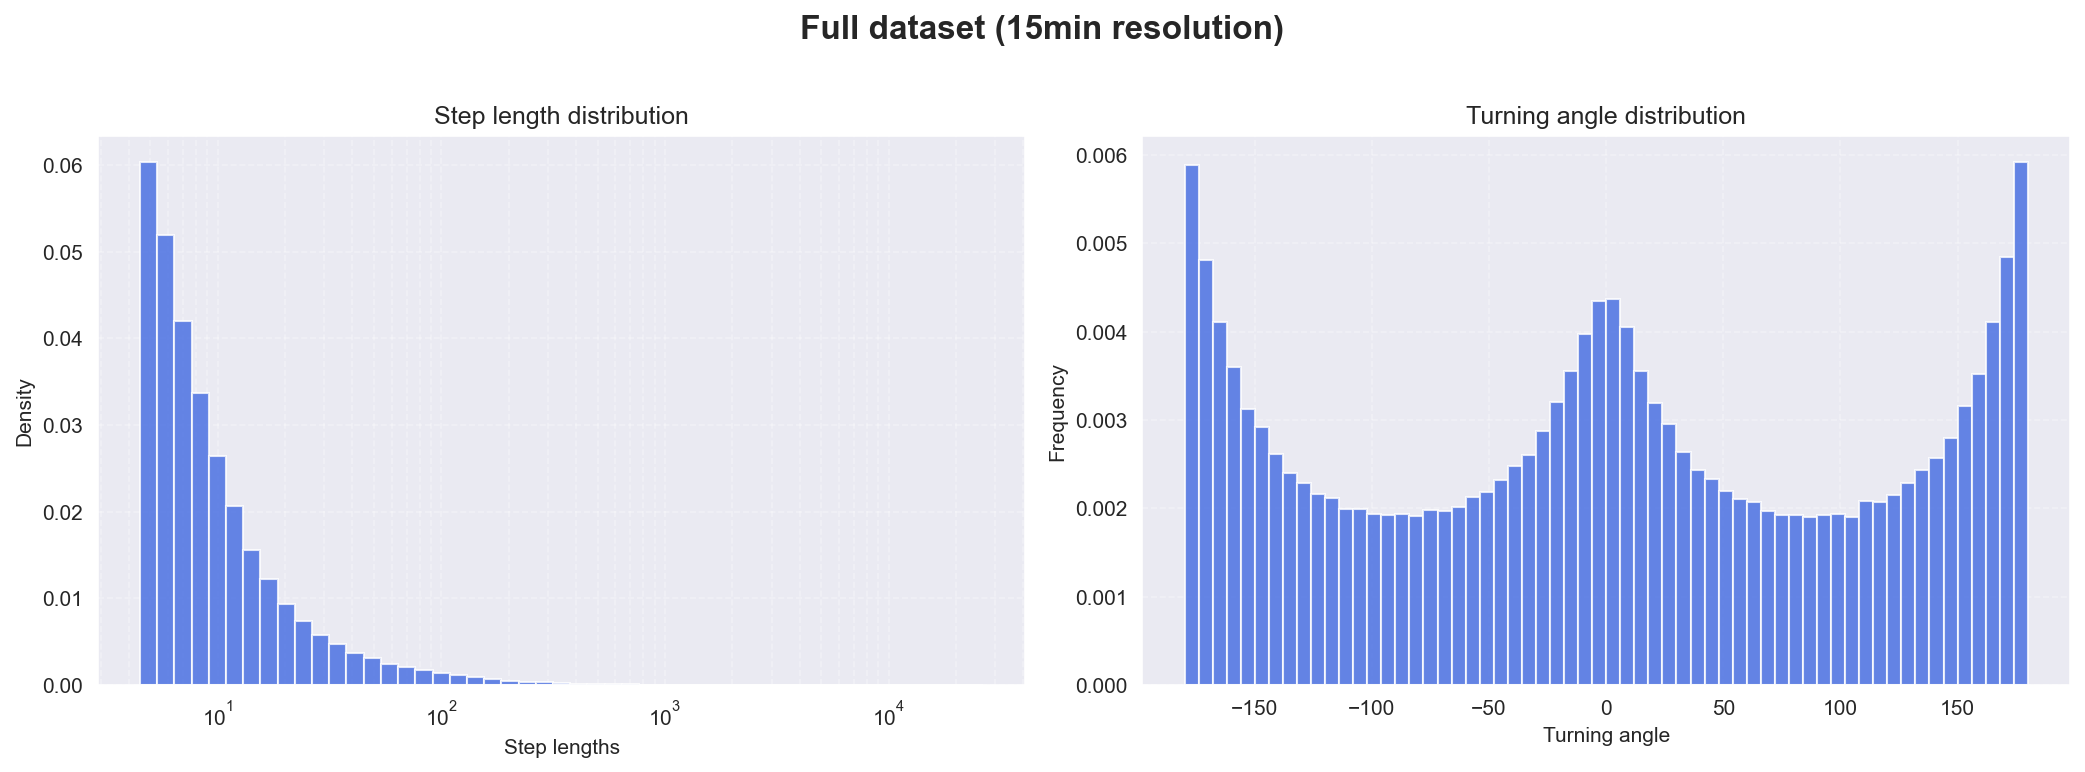

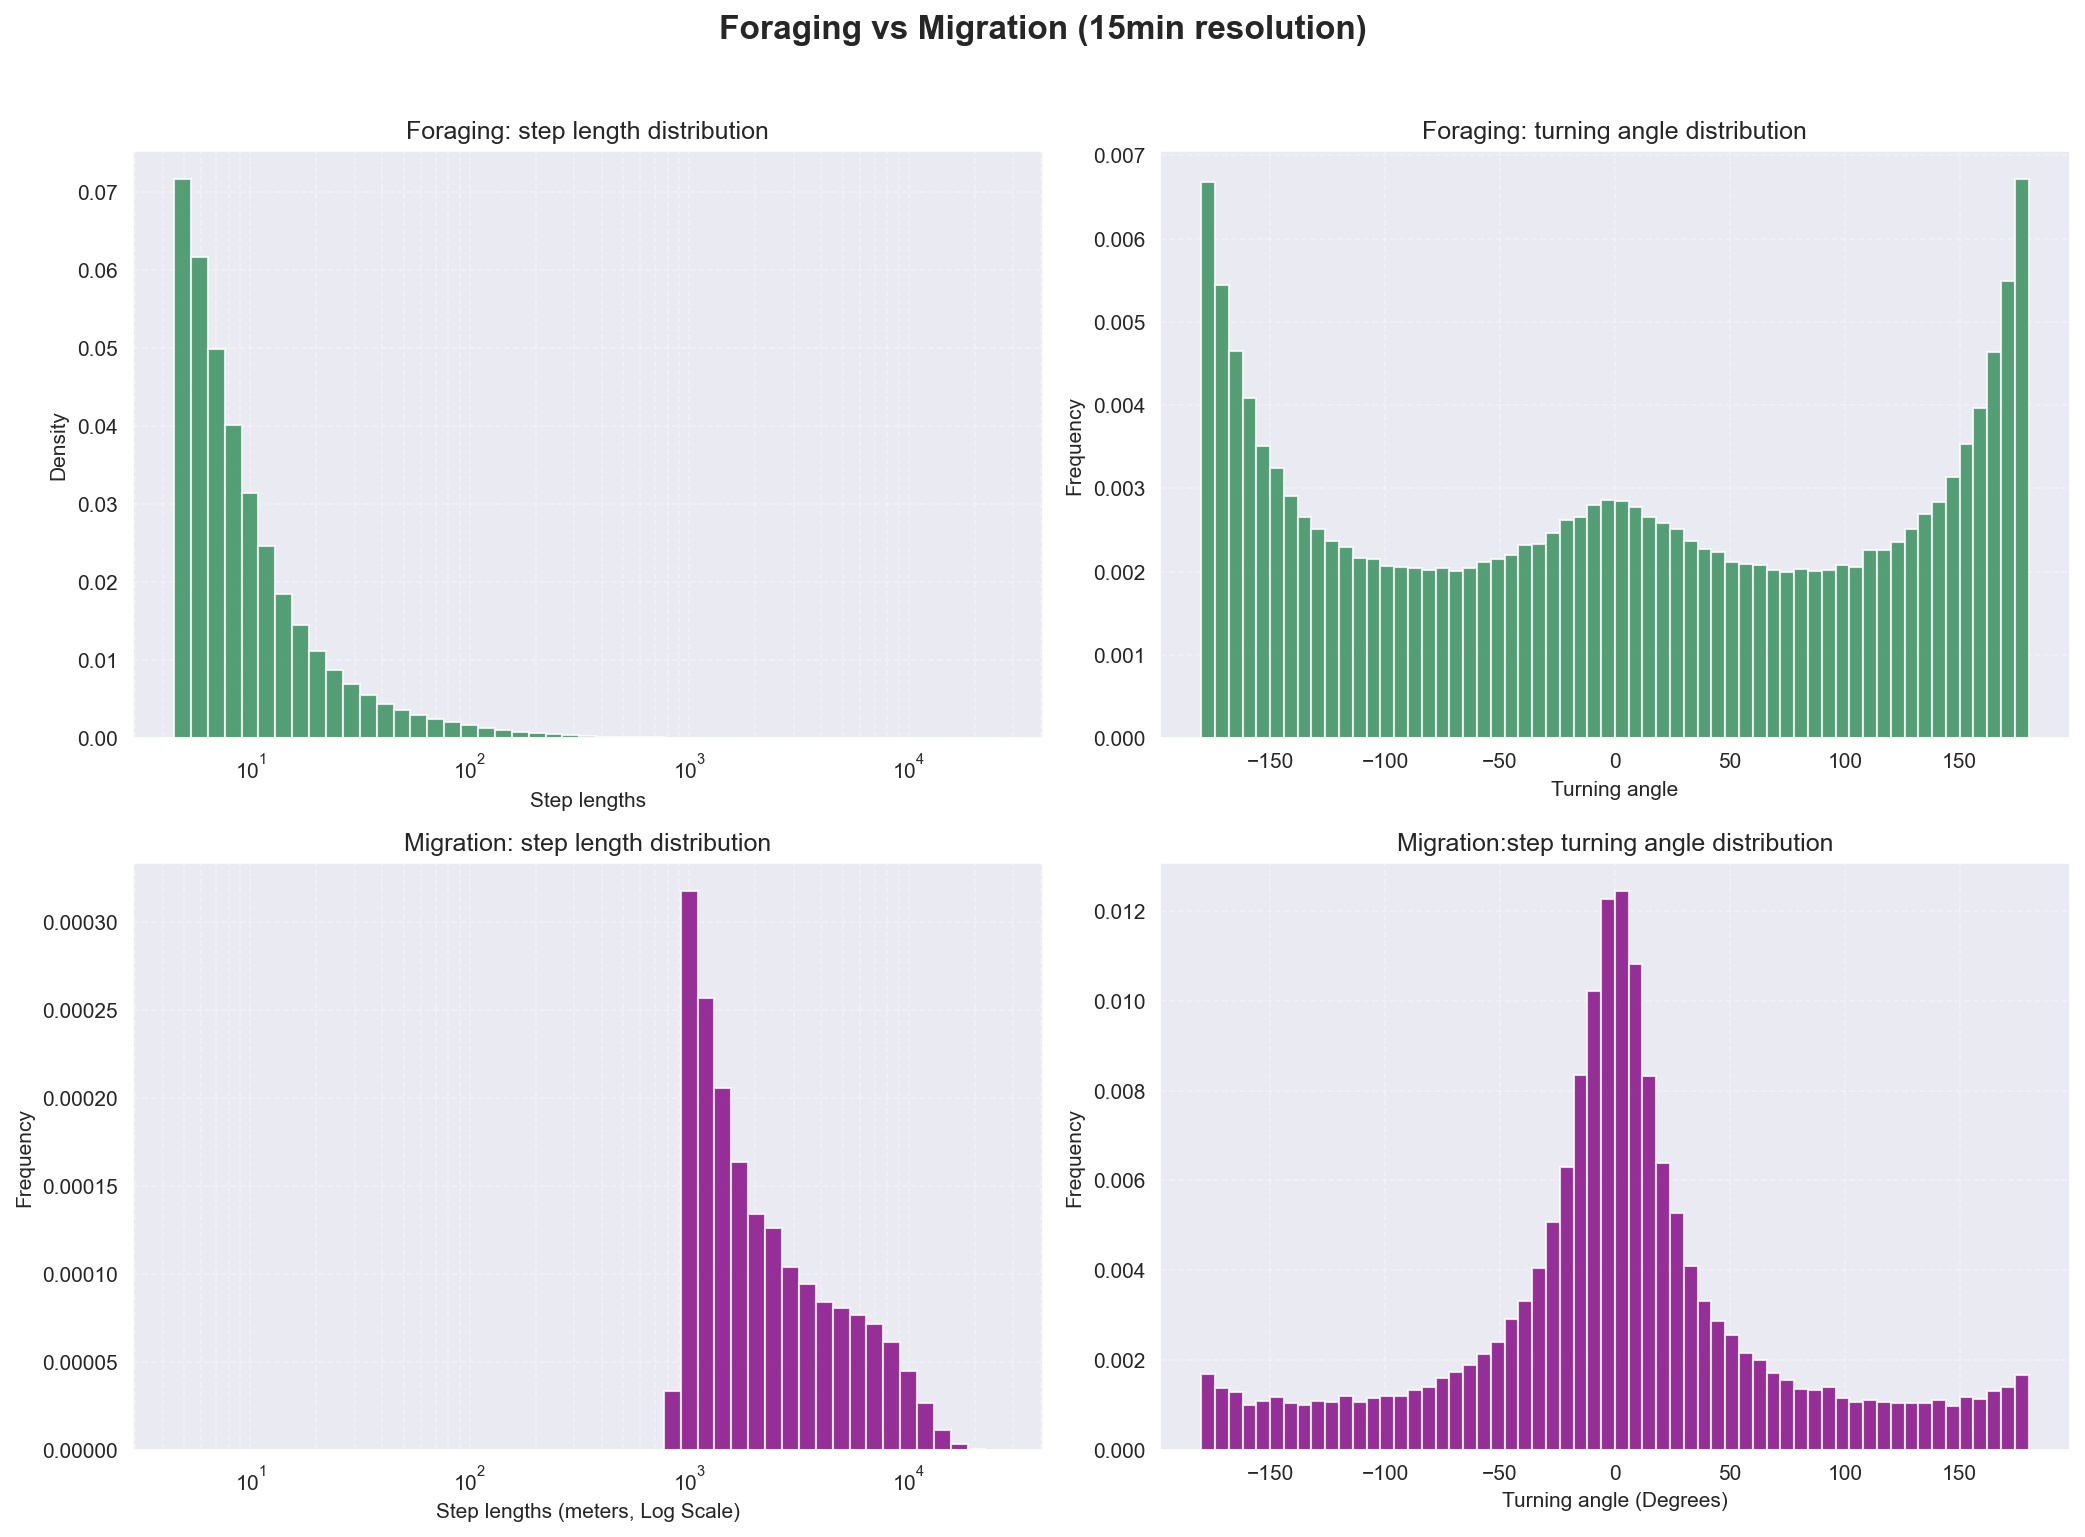

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371000.0 # Earth radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def bearing_vec(lat1, lon1, lat2, lon2):
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    x = np.sin(lo2-lo1)*np.cos(la2)
    y = np.cos(la1)*np.sin(la2) - np.sin(la1)*np.cos(la2)*np.cos(lo2-lo1)
    return np.degrees(np.arctan2(x, y)) % 360

df_whitestorks['timestamp'] = pd.to_datetime(df_whitestorks['timestamp'], format='ISO8601')

df_time = df_whitestorks.set_index('timestamp')

df_resampled = df_time.groupby('individual_id').resample('15min').first().dropna(subset=['lat', 'lon']).reset_index()

df_resampled = df_resampled.sort_values(by=['individual_id', 'timestamp']).reset_index(drop=True)

df_resampled['dt_sec'] = df_resampled.groupby('individual_id')['timestamp'].diff().dt.total_seconds()

df_resampled['next_lat'] = df_resampled.groupby('individual_id')['lat'].shift(-1)
df_resampled['next_lon'] = df_resampled.groupby('individual_id')['lon'].shift(-1)
df_resampled['prev_lat'] = df_resampled.groupby('individual_id')['lat'].shift(1)
df_resampled['prev_lon'] = df_resampled.groupby('individual_id')['lon'].shift(1)

df_resampled['step_m'] = haversine_vec(df_resampled['lat'], df_resampled['lon'], df_resampled['next_lat'], df_resampled['next_lon'])
df_resampled['speed_ms'] = df_resampled['step_m'] / df_resampled['dt_sec'].shift(-1) # Speed to next point

b_in = bearing_vec(df_resampled['prev_lat'], df_resampled['prev_lon'], df_resampled['lat'], df_resampled['lon'])
b_out = bearing_vec(df_resampled['lat'], df_resampled['lon'], df_resampled['next_lat'], df_resampled['next_lon'])
df_resampled['turn_angle'] = ((b_out - b_in) + 180) % 360 - 180
df_resampled = df_resampled.drop(columns=['next_lat', 'next_lon', 'prev_lat', 'prev_lon'])

MIN_SPEED = 0.005  
MAX_SPEED = 30.0  
MIN_TIME_GAP = 800.0
MAX_TIME_GAP = 1000.0

df_clean_15m = df_resampled.dropna(subset=['step_m', 'speed_ms', 'turn_angle', 'dt_sec']).copy()
#we shift dt_sec back 1 so we filter the time gap corresponding to the step
df_clean_15m['dt_sec_next'] = df_clean_15m.groupby('individual_id')['dt_sec'].shift(-1)

df_clean_15m = df_clean_15m[
    (df_clean_15m['speed_ms'] >= MIN_SPEED) & 
    (df_clean_15m['speed_ms'] <= MAX_SPEED) &
    (df_clean_15m['dt_sec_next'] >= MIN_TIME_GAP) & 
    (df_clean_15m['dt_sec_next'] <= MAX_TIME_GAP)
].copy()

# BEHAVIORAL SPLITTING 
# Threshold for storks: >1 m/s (3.6 km/h) is active flight, below is localized foraging
MODE_THRESHOLD = 1.0  

df_foraging = df_clean_15m[df_clean_15m['speed_ms'] <= MODE_THRESHOLD].copy()
df_migration = df_clean_15m[df_clean_15m['speed_ms'] > MODE_THRESHOLD].copy()

print(f"\n[Dataset Summaries]")
print(f"Total 15m steps retained: {len(df_clean_15m):,}")


fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Full dataset (15min resolution)", fontweight="bold", fontsize=16, y=1.02)

bins_step = np.logspace(np.log10(max(1, df_clean_15m['step_m'].min())), np.log10(df_clean_15m['step_m'].max()), 50)

axes[0].hist(df_clean_15m['step_m'], bins=bins_step, alpha=0.8, color='royalblue', edgecolor='white', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Step lengths')
axes[0].set_ylabel('Density')
axes[0].set_title('Step length distribution')
axes[0].grid(True, which="both", ls="--", alpha=0.3)

axes[1].hist(df_clean_15m['turn_angle'], bins=60, alpha=0.8, color='royalblue', edgecolor='white', density=True)
axes[1].set_xlabel('Turning angle')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Turning angle distribution')
axes[1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Foraging vs Migration (15min resolution)", fontweight="bold", fontsize=16, y=1.02)

bins_step = np.logspace(np.log10(max(1, df_clean_15m['step_m'].min())), np.log10(df_clean_15m['step_m'].max()), 50)

axes[0, 0].hist(df_foraging['step_m'], bins=bins_step, alpha=0.8, color='seagreen', edgecolor='white', density=True)
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Step lengths')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Foraging: step length distribution')
axes[0, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[0, 1].hist(df_foraging['turn_angle'], bins=60, alpha=0.8, color='seagreen', edgecolor='white', density=True)
axes[0, 1].set_xlabel('Turning angle')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Foraging: turning angle distribution')
axes[0, 1].grid(True, ls="--", alpha=0.3)


axes[1, 0].hist(df_migration['step_m'], bins=bins_step, alpha=0.8, color='purple', edgecolor='white', density = True)
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Step lengths (meters, Log Scale)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Migration: step length distribution')
axes[1, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[1, 1].hist(df_migration['turn_angle'], bins=60, alpha=0.8, color='purple', edgecolor='white', density=True)
axes[1, 1].set_xlabel('Turning angle (Degrees)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Migration:step turning angle distribution')
axes[1, 1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

The turning angle distributions look different for 2 modes of movement:
* **Foraging:** During slow movements, the bird turns constantly to cover a localized patch of resources.
* **Migration:** During high-speed movement we observe high directional persistance.

Now, we will fit and test stable distribution to the resampled observations for full dataset as well as foraging and migration mode separately.

In [ ]:
import os
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import levy_stable
import stabpy
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


behavioral_modes = {
    "Full": df_clean_15m,
    "Migration": df_migration,
    "Foraging": df_foraging
}

final_results = {}
MC_ITERATIONS = 500 

for mode_name, df_mode in behavioral_modes.items():
    print("=" * 85)
    print(mode_name)
    base_folder = f"stable_plots_resampled/{mode_name.lower()}"
    os.makedirs(f"{base_folder}/passed", exist_ok=True)
    os.makedirs(f"{base_folder}/failed", exist_ok=True)


    bird_counts = df_mode.groupby("individual_id").size()
    print(f"bird counts from {bird_counts.min()} to {bird_counts.max()}")
    filtered_birds = bird_counts[bird_counts.between(2000, 10000)].sort_values(ascending=False).index.tolist()

    print("=" * 85)
    print(f"{len(filtered_birds)} birds")
    print("=" * 85)

    all_birds_database = {}
    MC_ITERATIONS = 500 

    for rank, bird_id in enumerate(filtered_birds):

        df_bird_full = df_mode[df_mode["individual_id"] == bird_id].sort_values("timestamp")
        s_b = df_bird_full["step_m"].values
        total_obs = len(s_b)
        
        try:
            aq, sq, bq, mq = stabpy.stabcull(s_b)
        except Exception:
            aq, sq, bq, mq = 0, 0, 0, 0

        try:
            ar, sr, br, mr = stabpy.stabreg(s_b)
        except Exception:
            ar, sr, br, mr = None, None, None, None
            
        if ar is None:
            print(f"'{bird_id}' failed regression")
            continue  
        print("Estimated for full data", ar, sr, br, mr)
        np.random.seed(42)
        sample_size = min(total_obs, 10000)
        s_b_test = np.random.choice(s_b, size=sample_size, replace=False)
            

        test_res = custom_stabtest(s_b_test, ilp=MC_ITERATIONS)

        pvals = test_res[9:14]
        passing_tests_count = np.sum(pvals >= 0.05)
        
        safe_bird_name = str(bird_id).replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
        
        if passing_tests_count >= 3:
            status_folder = "passed"
            print(f"'{bird_id}' passed validation ({passing_tests_count}/5 tests accepted).")
        else:
            status_folder = "failed"
            print(f"'{bird_id}' failed validation ({passing_tests_count}/5 tests accepted).")
            
        # Save the FULL DATASET parameters to your database
        all_birds_database[bird_id] = {
            "Total Observations (n)": total_obs,
            "Sample Evaluation Size": sample_size,
            "Passing Tests Count": passing_tests_count,
            "Status": "Passed" if passing_tests_count >= 3 else "Failed",
            "alpha_cull": aq, "beta_cull": bq, "sigma_cull": sq, "mu_cull": mq,
            "alpha_reg": ar, "beta_reg": br, "sigma_reg": sr, "mu_reg": mr,
            "p_KS": pvals[0], "p_Kuiper": pvals[1], "p_CvM": pvals[2], "p_Watson": pvals[3], "p_AD": pvals[4],
            "stat_KS": test_res[4], "stat_Kuiper": test_res[5], "stat_CvM": test_res[6], "stat_Watson": test_res[7], "stat_AD": test_res[8]
        }

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle(f"{bird_id}", fontweight="bold", fontsize=14)
        
        ax1 = axes[0, 0]
        bins = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 50)
        
        ax1.hist(s_b, bins=bins, density=True, alpha=0.5, color="royalblue", edgecolor="white", label="Empirical steps (Full)")
        
        levy_stable.parameterization = 'S0'
        x_grid = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 300)
        
        pdf_fitted = levy_stable.pdf(x_grid, ar, br, loc=mr, scale=sr)
        
        ax1.plot(x_grid, pdf_fitted, color="darkorange", lw=2.5, label=f"Fitted PDF ($\\alpha$={ar:.2f})")
        ax1.set_xscale("log")
        ax1.set_xlabel("Step lengths (meters)")
        ax1.set_ylabel("Probability density")
        ax1.set_title('Histogram with PDF')
        ax1.grid(True, which="both", ls="--", alpha=0.3)
        ax1.legend()

        ax2 = axes[0, 1]
        s_b_sorted = np.sort(s_b)
        theoretical_cdf = stabpy.stabcdf(s_b_sorted, ar, sr, br, mr)
        empirical_cdf = np.arange(1, len(s_b)+1) / (len(s_b)+1)
        sample_indices = np.linspace(0, len(s_b)-1, min(1000, len(s_b))).astype(int)
        
        ax2.scatter(theoretical_cdf[sample_indices], empirical_cdf[sample_indices], 
                    color="crimson", alpha=0.5, s=8, label="empirical quantiles", zorder=3)
        ax2.plot([0, 1], [0, 1], 'k--', label='theoretical fit', lw=1.5, zorder=2)
        ax2.set_xlabel('Theoretical quantiles')
        ax2.set_ylabel('Empirical quantiles')
        ax2.set_title('Q-Q Plot')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        ax3 = axes[1, 0]
        ax3.plot(s_b[:500], color="teal", linewidth=1.0, alpha=0.8)
        ax3.set_xlabel('($t$)')
        ax3.set_ylabel('Step (m)')
        ax3.set_title('First 500 steps')
        ax3.grid(True, alpha=0.3)
        
        ax4 = axes[1, 1]
        params_quant = [aq, bq]
        params_reg = [ar, br]
        x_pos = np.arange(2)
        width = 0.35
        ax4.bar(x_pos - width/2, params_quant, width, label='Quantile (stabcull)', color="orange", alpha=0.8)
        ax4.bar(x_pos + width/2, params_reg, width, label='Regression (stabreg)', color="purple", alpha=0.8)
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(['$\\alpha$', '$\\beta$'])
        ax4.set_title('Parameter estimation comparison')
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        dashboard_destination = os.path.join(base_folder, status_folder, f"dashboard_{safe_bird_name}.png")
        plt.savefig(dashboard_destination, dpi=150, bbox_inches='tight')
        plt.close()


    per_bird_df3 = pd.DataFrame(all_birds_database).T

    column_ordering = [
        "Total Observations (n)", "Sample Evaluation Size", "Passing Tests Count", "Status",
        "alpha_cull", "beta_cull", "sigma_cull", "mu_cull",
        "alpha_reg", "beta_reg", "sigma_reg", "mu_reg",
        "p_KS", "p_Kuiper", "p_CvM", "p_Watson", "p_AD",
        "stat_KS", "stat_Kuiper", "stat_CvM", "stat_Watson", "stat_AD"
    ]
    per_bird_df3 = per_bird_df3.reindex(columns=column_ordering)


    display(per_bird_df3.round(4))

Full
bird counts from 1 to 20223
19 birds
Estimated for full data 0.3766792690135369 11.696288477107993 0.6411687023099057 3515.926670529281

 Stabtest fitted params Alpha=0.3767, Sigma=11.6963, Beta=0.6412, Mu=3515.9267


100%|██████████| 500/500 [03:14<00:00,  2.57it/s]


'Kakau (DER AN864)' failed validation (0/5 tests accepted).
Estimated for full data 0.39386019172347125 13.968213756640905 1.0 3.7514008485199484

 Stabtest fitted params Alpha=0.3939, Sigma=13.9682, Beta=1.0000, Mu=3.7514


100%|██████████| 500/500 [02:46<00:00,  3.00it/s]


'Dilya' passed validation (5/5 tests accepted).
Estimated for full data 0.4114056325366668 12.592703197268923 0.936805895955162 4.17207780206627

 Stabtest fitted params Alpha=0.4114, Sigma=12.5927, Beta=0.9368, Mu=4.1721


...

100%|██████████| 500/500 [00:41<00:00, 12.16it/s]


'C708' passed validation (5/5 tests accepted).
Estimated for full data 0.5233778896002685 4.455605886300793 0.9499430434535974 4.1636202623581795

 Stabtest fitted params Alpha=0.5234, Sigma=4.4556, Beta=0.9499, Mu=4.1636


100%|██████████| 500/500 [00:36<00:00, 13.60it/s]


'C70V' passed validation (5/5 tests accepted).


,Total Observations (n),Sample Evaluation Size,Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,...,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
Silvia (GRA51159),9768,9768,0,Failed,1.086009,1.0,42.434711,561.342207,0.415972,1.0,...,0.0,0.0,0.0,0.0,0.0,98.954306,98.990621,3256.333292,814.066656,inf
PLG 5P312,9447,9447,0,Failed,1.684213,1.0,115.575709,104.615986,0.290829,1.0,...,0.0,0.0,0.0,0.0,0.0,97.316811,97.353148,3149.333291,787.316656,inf
Kakau (DER AN864),9075,9075,0,Failed,1.444005,1.0,36.394581,90.67244,0.38816,1.0,...,0.0,0.0,0.0,0.0,0.0,95.383949,95.420314,3025.333289,756.316656,inf
BraveHeart (DER AP926),8759,8759,0,Failed,1.10532,1.0,43.457534,462.155696,0.371321,1.0,...,0.0,0.0,0.0,0.0,0.0,93.710705,93.747094,2919.999954,729.983322,inf
DER AP922,8122,8122,5,Passed,1.107761,1.0,32.350197,332.352301,0.416321,-1.0,...,0.786,0.234,0.776,0.254,0.772,73.601004,84.272777,1797.167719,644.389492,9699.662879
DER AR440,8086,8086,1,Failed,1.599514,1.0,110.566251,130.217646,0.286778,0.565512,...,0.0,0.0,0.0,0.0,0.274,87.187515,90.020623,2450.792989,673.288628,20193.050322
Dilya,7951,7951,0,Failed,1.052849,1.0,33.826143,693.478113,0.404445,0.027067,...,0.0,0.0,0.0,0.0,0.0,80.254709,85.52748,2177.451546,646.812681,14527.113066
DER AP921,4813,4813,0,Failed,0.675841,1.0,5.602922,-3.609356,0.540006,1.0,...,0.008,0.0,0.002,0.0,0.002,3.344953,5.970812,3.615852,3.614087,33.046112
DER AR436,4258,4258,1,Failed,1.182889,1.0,45.247362,276.62421,0.34773,0.725606,...,0.0,0.0,0.0,0.0,0.234,64.100242,65.244404,1347.060734,354.178607,13081.205655
C666,3965,3965,0,Failed,1.490375,1.0,81.683624,142.244473,0.345048,1.0,...,0.0,0.0,0.0,0.0,0.0,63.089993,63.127057,1321.999899,330.483308,inf


After resampling more birds passed statistical Goodness-of-fit tests with higher p-values. 

## 3. Turning angle analysis


### Dependance with lengths

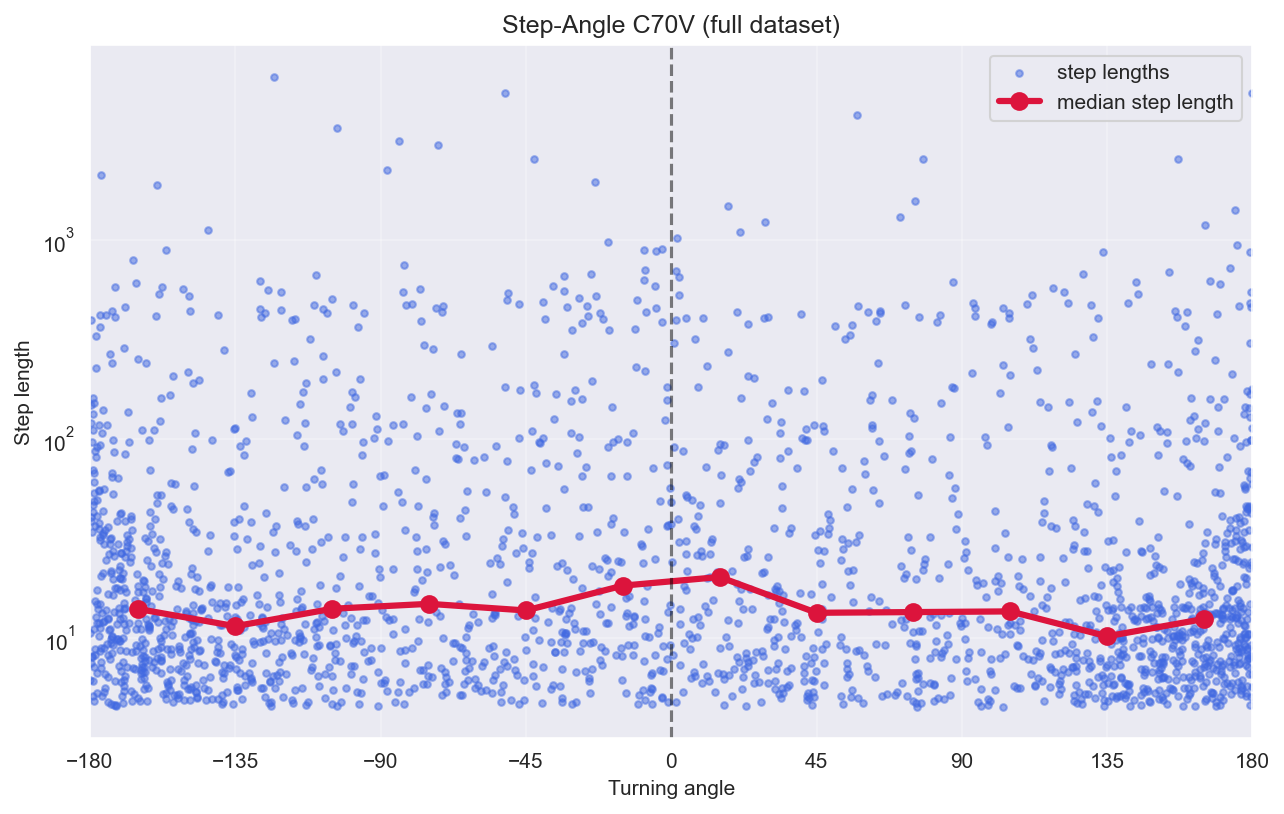

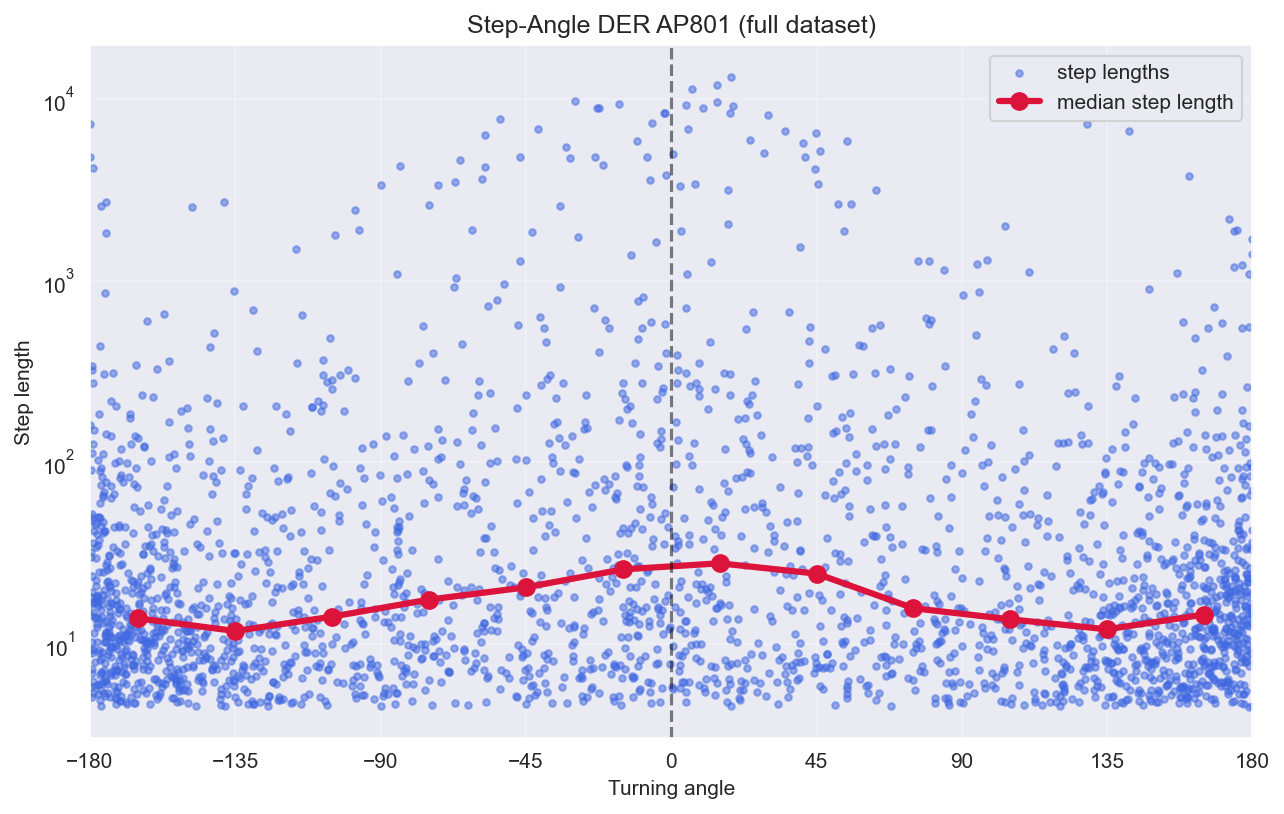

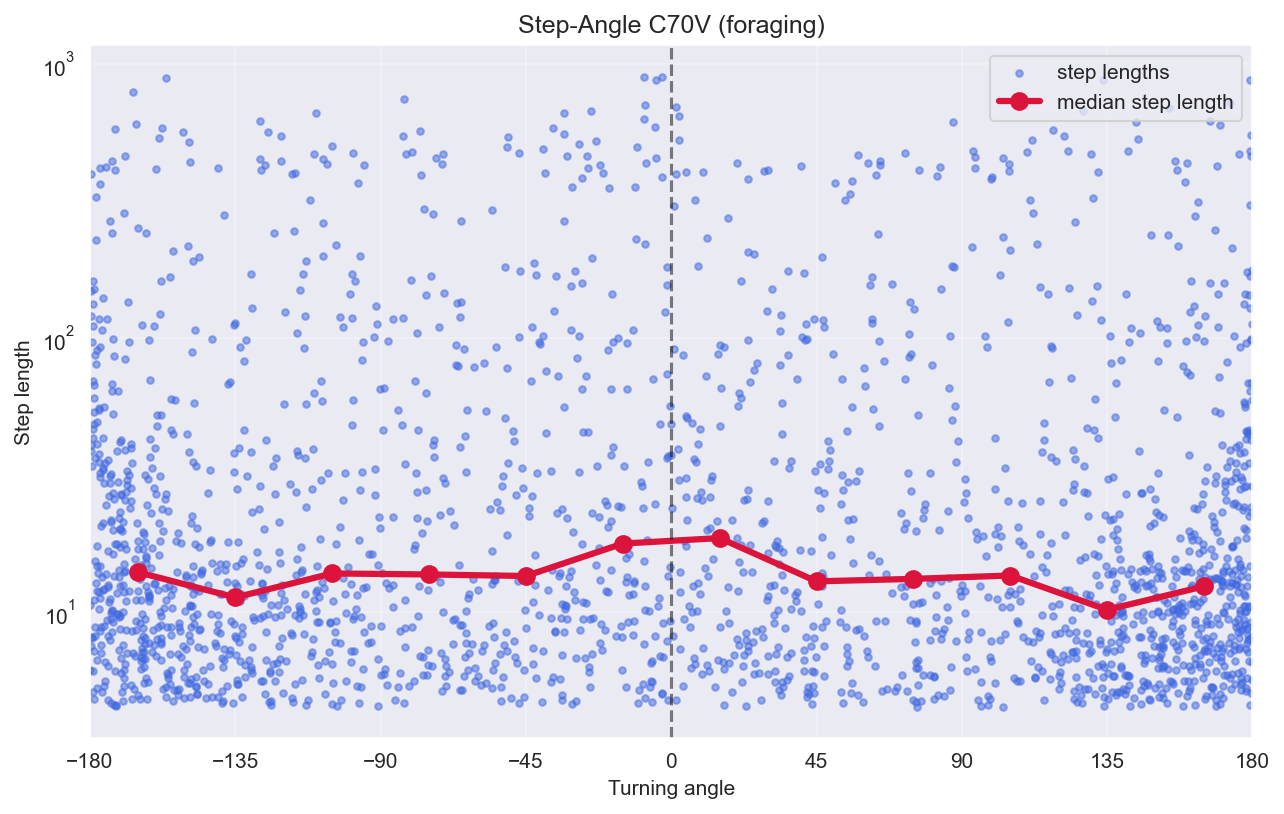

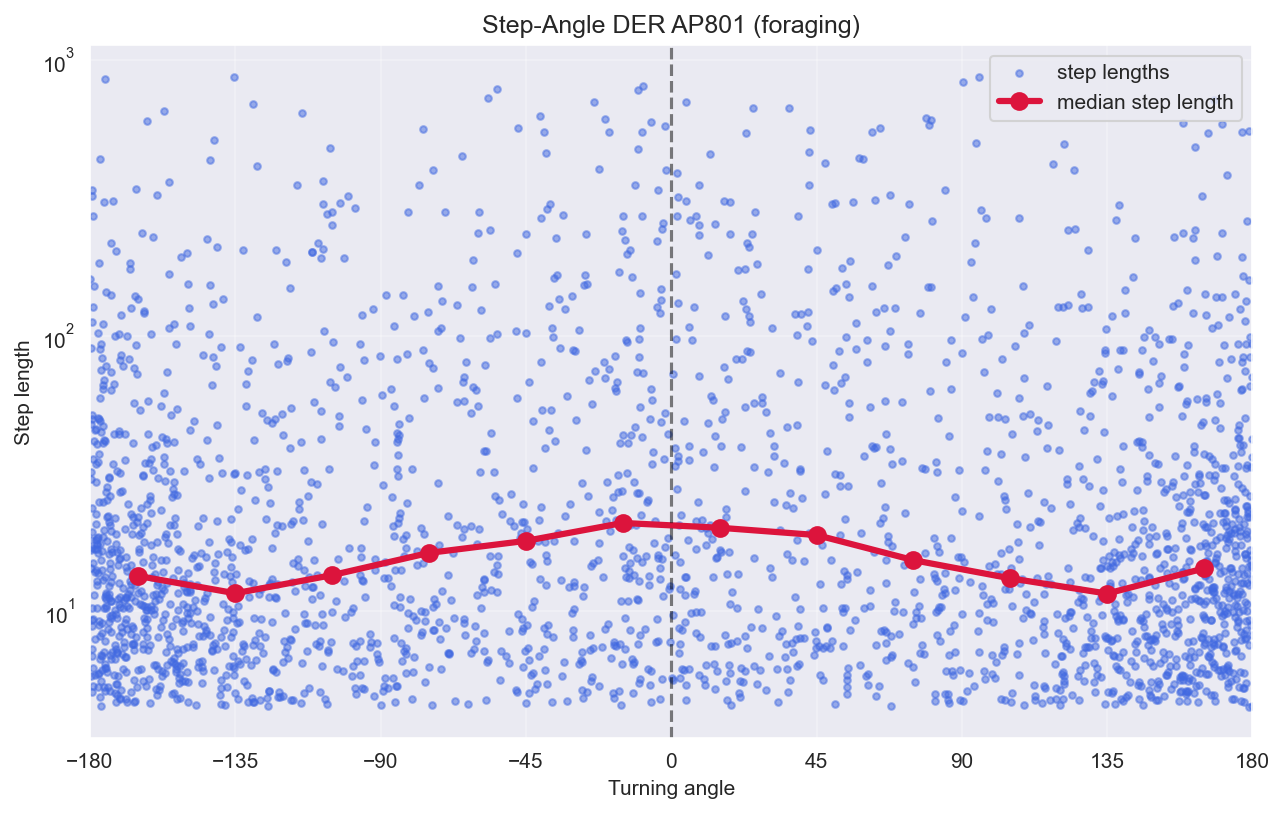

In [45]:
def empirical_angle_dependence(bird_ids, df_mode, mode_name):
    for bird_id in bird_ids:

        df_bird = df_mode[df_mode['individual_id'] == bird_id].dropna(subset=['step_m', 'turn_angle']).copy()
        if len(df_bird) < 100:
            return
            
        steps = df_bird['step_m'].values
        angles = df_bird['turn_angle'].values
        
        bins = np.arange(-180, 181, 30)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # we use median instead of mean because heavy tails skew the mean heavily
        median_steps = []
        for i in range(len(bins)-1):
            mask = (angles >= bins[i]) & (angles < bins[i+1])
            if np.any(mask):
                median_steps.append(np.median(steps[mask]))
            else:
                median_steps.append(np.nan)
                
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.scatter(angles, steps, alpha=0.5, color='royalblue', s=10, label='step lengths')
        
        ax.plot(bin_centers, median_steps, 'crimson', marker='o', lw=3, markersize=8, label='median step length')
        
        ax.set_yscale('log')
        ax.set_xlim(-180, 180)
        ax.set_xticks(np.arange(-180, 181, 45))
        ax.set_xlabel('Turning angle')
        ax.set_ylabel('Step length')
        ax.set_title(f'Step-Angle {bird_id} ({mode_name})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        
        plt.show()

empirical_angle_dependence(["C70V", "DER AP801"], df_clean_15m, "full dataset")
empirical_angle_dependence([ "C70V", "DER AP801"], df_foraging, "foraging")

Total Pooled Observations: 368,568


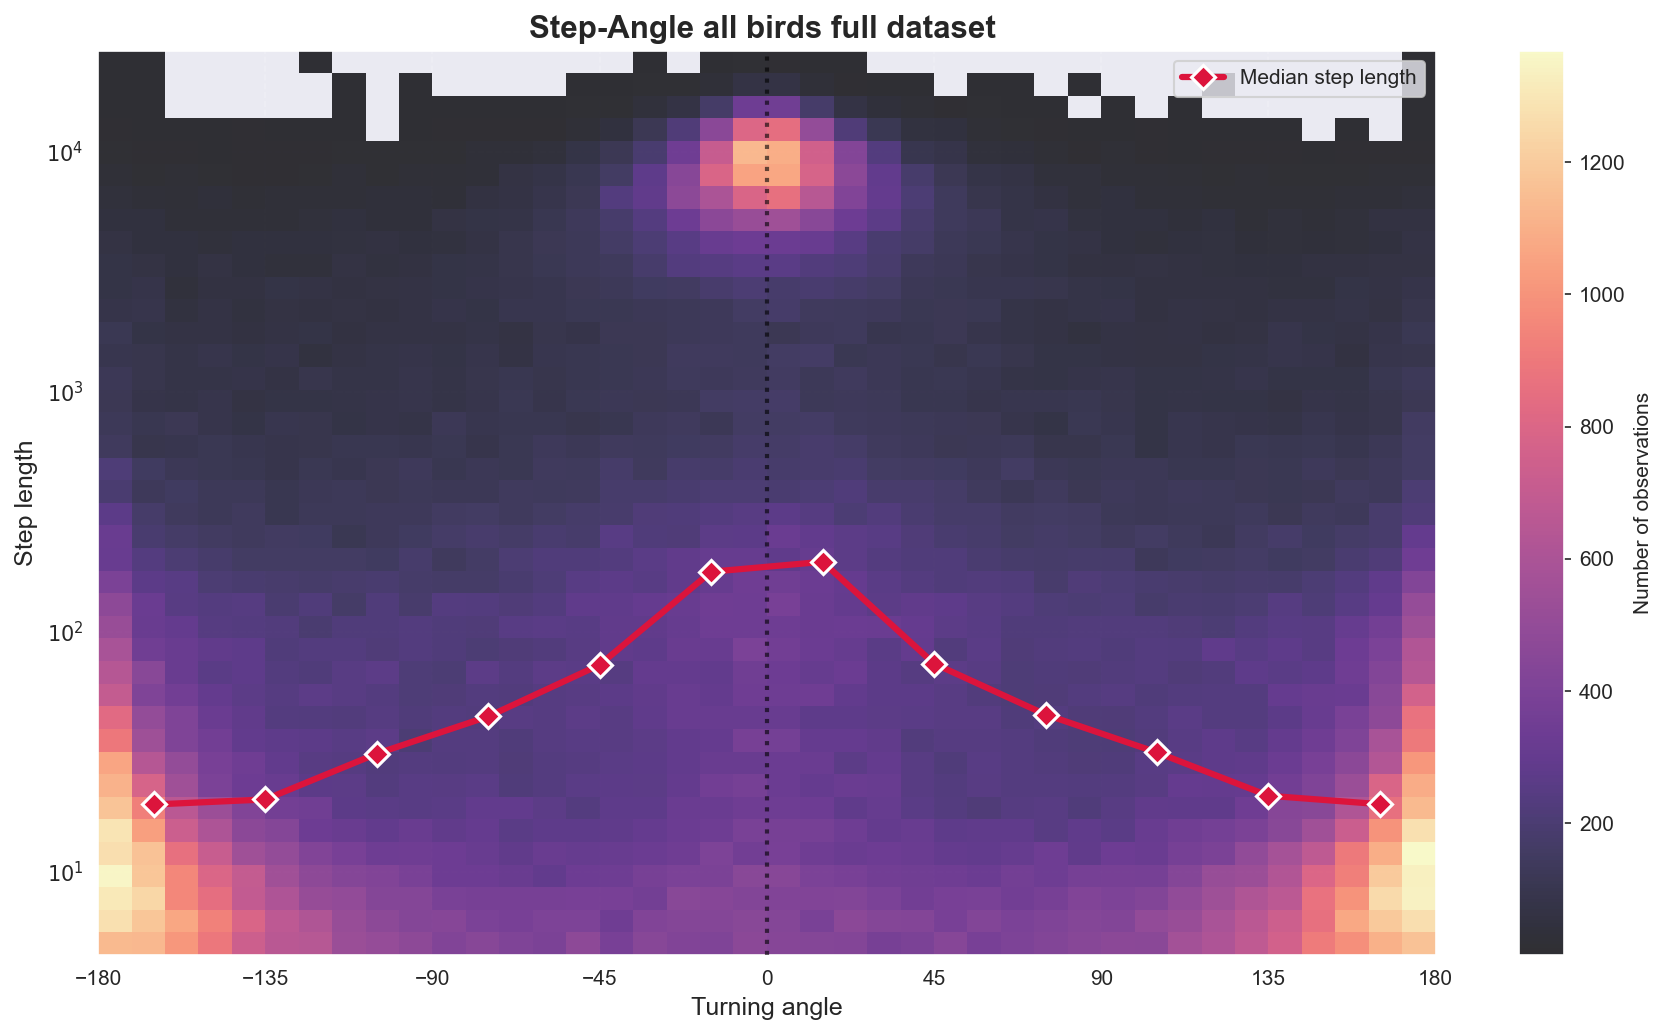

Total Pooled Observations: 310,276


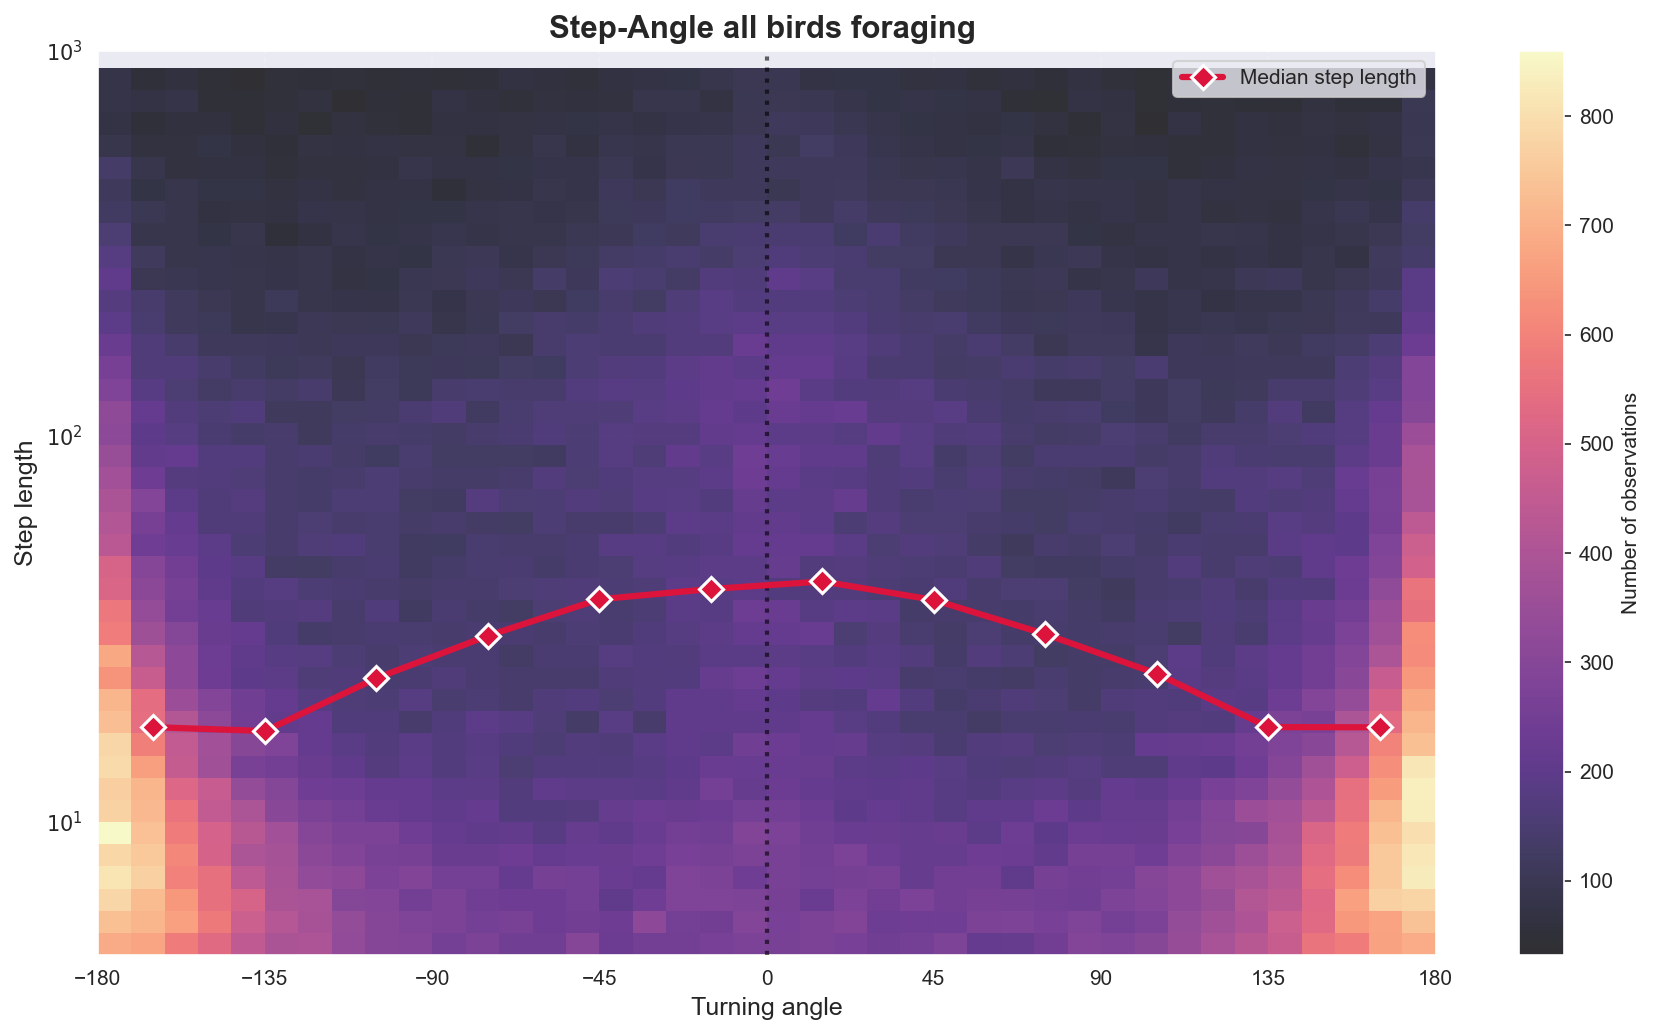

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # We will use seaborn for the beautiful KDE plots!

def pooled_empirical_angle_dependence(df_mode, mode_name):

    df_pooled = df_mode.dropna(subset=['step_m', 'turn_angle']).copy()
    
    total_obs = len(df_pooled)
        
    print(f"Total Pooled Observations: {total_obs:,}")
    
    steps = df_pooled['step_m'].values
    angles = df_pooled['turn_angle'].values
    
    bins = np.arange(-180, 181, 30)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    median_steps = []
    
    for i in range(len(bins)-1):
        mask = (angles >= bins[i]) & (angles < bins[i+1])
        if np.any(mask):
            median_steps.append(np.median(steps[mask]))
        else:
            median_steps.append(np.nan)
            
    fig, ax = plt.subplots(figsize=(12, 7))
    
    log_steps = np.log10(steps)
        
    h = ax.hist2d(angles, log_steps, bins=[40, 40], cmap='magma', cmin=1, alpha=0.8)
    fig.colorbar(h[3], ax=ax, label='Number of observations')
    if mode_name=="full dataset":
        ax.set_yticks([1, 2, 3, 4])
        ax.set_yticklabels([f"$10^{i}$" for i in range(1,5)])
    else:
        ax.set_yticks([1, 2, 3])
        ax.set_yticklabels([f"$10^{i}$" for i in range(1,4)])
    

    median_plot = np.log10(median_steps)        
    ax.plot(bin_centers, median_plot, 'crimson', marker='D', lw=3, markersize=8, 
            markeredgecolor='white', markeredgewidth=1.5, label='Median step length', zorder=5)
    
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 45))
    ax.set_xlabel('Turning angle', fontsize=12)
    ax.set_ylabel('Step length', fontsize=12)
    ax.set_title(f'Step-Angle all birds {mode_name} ', fontsize=15, fontweight='bold')
    
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2, linestyle='--')
    
    ax.axvline(0, color='black', linestyle=':', lw=2, alpha=0.6, zorder=4)
    
    plt.tight_layout()
    plt.show()

pooled_empirical_angle_dependence( df_clean_15m, "full dataset")

pooled_empirical_angle_dependence( df_foraging, "foraging")

In [68]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kruskal

def verify_statistical_dependence(df_mode, mode_name, bird_id=None):
    print("="*20)
    print(mode_name)

    if bird_id:
        print("bird:", bird_id)
        df_pooled = df_mode[df_mode["individual_id"] == bird_id].dropna(subset=['step_m', 'turn_angle']).copy()
    else:
        df_pooled = df_mode.dropna(subset=['step_m', 'turn_angle']).copy()
    
    steps = df_pooled['step_m'].values
    angles = df_pooled['turn_angle'].values
    
    # We take the absolute angle (deviation from 0) 
    # Hypothesis: as absolute angle increases, step length decreases (Negative correlation)
    abs_angles = np.abs(angles)
    rho, p_val_spearman = spearmanr(abs_angles, steps, alternative="less")
    
    print("\n1. Spearman Rank Correlation (Absolute angle vs step)")
    print(f"Spearman's rho : {rho:.4f}")
    print(f"p-value: {p_val_spearman:.4f}")
        
    if rho < 0:
        print("Confirmed. As the stork turns sharper, its steps get exponentially shorter.")
        
    # 2. Kruskal-Wallis H-Test (Non-parametric ANOVA across bins)
    # Hypothesis: The median step lengths across our 30-degree bins are not equal.
    bins = np.arange(-180, 181, 30)
    binned_steps = []
    
    for i in range(len(bins)-1):
        mask = (angles >= bins[i]) & (angles < bins[i+1])
        if np.sum(mask) > 10: # only test bins with enough data
            binned_steps.append(steps[mask])
            
    stat_kw, p_val_kw = kruskal(*binned_steps)
    
    print("\n2. Kruskal-Wallis H-Test (Comparing medians across 30deg bins)")
    print(f"H-statistic: {stat_kw:.2f}")
    print(f"p-value: {p_val_kw:.4f}")
        
    print("Confirmed. The step length distribution changes depending on the bird's heading.")

top_birds = ["Willi (DER AN863)", "C70V", "DER AP801", "DER AP927"]
verify_statistical_dependence(df_clean_15m, "Full dataset")
verify_statistical_dependence(df_clean_15m, "Full dataset", top_birds[0])

verify_statistical_dependence(df_foraging, "Foraging")
verify_statistical_dependence(df_foraging, "Foraging", top_birds[0])

Full dataset

1. Spearman Rank Correlation (Absolute angle vs step)
Spearman's rho : -0.3179
p-value: 0.0000
Confirmed. As the stork turns sharper, its steps get exponentially shorter.

2. Kruskal-Wallis H-Test (Comparing medians across 30deg bins)
H-statistic: 39785.50
p-value: 0.0000
Confirmed. The step length distribution changes depending on the bird's heading.
Full dataset
bird: Willi (DER AN863)

1. Spearman Rank Correlation (Absolute angle vs step)
Spearman's rho : -0.0878
p-value: 0.0000
Confirmed. As the stork turns sharper, its steps get exponentially shorter.

2. Kruskal-Wallis H-Test (Comparing medians across 30deg bins)
H-statistic: 40.93
p-value: 0.0000
Confirmed. The step length distribution changes depending on the bird's heading.
Foraging

1. Spearman Rank Correlation (Absolute angle vs step)
Spearman's rho : -0.1548
p-value: 0.0000
Confirmed. As the stork turns sharper, its steps get exponentially shorter.

2. Kruskal-Wallis H-Test (Comparing medians across 30deg bins

The correlation analysis reveals a structural dependency within the behavior of the White Stork. 

Standard theoretical random walk models, including pure 2D Lévy flights, operate under the assumption of **isotropy**: step lengths ($L$) and turning angles ($\theta$) are independent random variables. However, the smoothed density heatmap and pooled median trajectory demonstrate a severe cross-dependency, verified statistically for pooled observations and individual bird for full data and for foraging only.

Because the generation of heavy-tailed spatial steps is conditionally dependent on directional persistence, we must reject the isotropic Lévy flight hypothesis. To accurately model white stork movement, the framework must integrate this correlation, for example through a Correlated Random Walk.

____
## Potential next steps for last presentation?

We could turn to simulations without data now (like for drone search topic) to show practical aplications - how to optimally perform foraging/searching, based on empirical bird data? Could be more interesting to show
 **To discuss**

## Trajectories simulation
- Levy flights
- Brownian motion
- Correlated Levy Flight - step-angle relation
- ...

## Optimal foraging hypothesis - comparison with Brownian baseline
- metrics for temporal coverage or place randomly targts and calculate how many found (we can check articles I found for swarm robotics I think they are on drive)
- simulate something line drone search with different movement simulation (Brownian, Levy, CLF from previous point)